<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# Triage Review: Fewer Machine Reviews, More Failures Caught

This notebook studies a machine triage workflow where the goal is not only to predict failures well, but to turn model scores into a practical review plan.

Each machine receives a failure risk score. We then rank machines by that score and ask a business question: if the review team can only inspect a limited number of machines, which model gives the best review queue?

The notebook follows four steps:

1. prepare and inspect the data  
2. compare candidate models on the training and validation workflow  
3. measure how each model behaves when only the top ranked machines are reviewed  
4. choose the lowest cost review plan under different cost assumptions

The key operating rule in this notebook is a ranked queue rule, not a fixed threshold rule:

review the top k machines by predicted failure probability, where k is the available review capacity
</div>

</div>

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">
    
# 1. Data and target

The dataset contains machine level observations and a binary target called `fail`.

The feature set includes operational and environmental signals such as footfall, air quality related measures, VOC, RP, IP, and temperature. The target indicates whether the machine failed.

At this stage the goal is simple: confirm the schema, inspect a few rows, and verify that the target is suitable for supervised classification.

</div>

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 2. Imports and settings

This section loads the libraries used in the rest of the notebook and sets the main run settings.

The constants at the bottom control the workflow:

- `TARGET = "fail"` tells the notebook which column to predict
- `RANDOM_STATE = 42` keeps the data split reproducible
- `TEST_SIZE = 0.20` keeps 20% of the rows for the final test set
- `CV_FOLDS = 5` uses five fold cross validation when screening models
- `VALIDATION_SIZE = 0.25` splits the remaining training data again so threshold choices are made on validation, not on test

So this block does not just import code. It fixes the setup the rest of the notebook will follow.

</div>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.patches import Rectangle

from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

TARGET = "fail"
RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
VALIDATION_SIZE = 0.50

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">
    
# 3. Load data

This section reads the labeled dataset into a dataframe.

The **predictor columns** are `footfall`, `tempMode`, `AQ`, `USS`, `CS`, `VOC`, `RP`, `IP`, and `Temperature`.


The target is `fail`.

The code below loads the file, checks that `fail` is present, and shows the first few rows so I can confirm the table loaded as expected before doing any cleaning or modeling.

</div>

In [2]:
def load_data(path: str, target: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    if df.empty:
        raise ValueError("Loaded dataframe is empty.")

    if target not in df.columns:
        raise ValueError(f"Missing target column: {target}")

    return df


DATA_PATH = "/kaggle/input/datasets/umerrtx/machine-failure-prediction-using-sensor-data/data.csv"
df = load_data(DATA_PATH, TARGET)

display(df.head())

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 4. Remove duplicates and do a quick data check

I remove exact duplicate rows before modeling, then check the cleaned table for missing values, class balance in `fail`, and feature scale.

Findings:
- one exact duplicate pattern in the raw data, so I remove it
- no missing values in the cleaned table
- `fail` is split about `58.3%` for `0` and `41.7%` for `1`

Because the target is not fully balanced, accuracy alone is not enough, so I also use `ROC AUC`, `average precision`, and `F1`.

Some features are on very different numeric scales, especially `footfall`. That mainly affects linear models, so later I scale them for Logistic Regression so larger values do not dominate the fit more than the actual pattern.

</div>

In [3]:
duplicate_rows = df[df.duplicated(keep=False)]

print(f"Original shape: {df.shape}")

if duplicate_rows.empty:
    print("Duplicate rows found: 0")
else:
    print(f"Duplicate rows found: {len(duplicate_rows)}")
    display(duplicate_rows.reset_index())

df = df.drop_duplicates().reset_index(drop=True)

target_counts = df[TARGET].value_counts().sort_index()
target_props = df[TARGET].value_counts(normalize=True).sort_index()

print(f"\nCleaned shape: {df.shape}")
print(f"Missing values: {int(df.isnull().sum().sum())}")

print("\nTarget distribution")
for label, count in target_counts.items():
    print(f"{label}: {count:,} ({target_props[label]:.1%})")

summary = (
    df.drop(columns=[TARGET])
      .describe()
      .T[["min", "50%", "max"]]
      .rename(columns={"50%": "median"})
)

display(summary)

Original shape: (944, 10)
Duplicate rows found: 2


,index,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,730,31,5,3,3,6,1,48,6,21,0
1,766,31,5,3,3,6,1,48,6,21,0



Cleaned shape: (943, 10)
Missing values: 0

Target distribution
0: 550 (58.3%)
1: 393 (41.7%)


,min,median,max
footfall,0.0,22.0,7300.0
tempMode,0.0,3.0,7.0
AQ,1.0,4.0,7.0
USS,1.0,3.0,7.0
CS,1.0,6.0,7.0
VOC,0.0,2.0,6.0
RP,19.0,44.0,91.0
IP,1.0,4.0,7.0
Temperature,1.0,17.0,24.0


<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 5. Separate predictors and target

Here, I split the cleaned table into inputs and labels.

- `X` holds the predictor columns
- `y` holds the target column, `fail`

This is a small step, but it sets up everything that follows. The train, validation, and test split is done from `X` and `y`, and every model later in the notebook is fit on that same separation.

</div>

In [4]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 6. Build train, validation, and test sets

This section gives each split a separate job.

The code first holds out the test set. Then it splits the remaining rows again to create a validation set.

That leaves three parts:

- training set for fitting and comparing models
- validation set for choosing thresholds
- test set for the final check only

This split matters because the notebook is not only comparing models. It is also choosing a decision threshold later. That threshold needs to be chosen on validation data, not on the final test set.

The table below shows how many rows end up in each split and whether the failure rate stays similar across them. That is a quick check that the split is reasonable before model training starts.

</div>

In [5]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

split_summary = pd.DataFrame({
    "set": ["full data", "train", "validation", "test"],
    "rows": [len(y), len(y_train), len(y_val), len(y_test)],
    "failure rate": [y.mean(), y_train.mean(), y_val.mean(), y_test.mean()]
})

split_summary["failure rate"] = split_summary["failure rate"].map(lambda v: f"{v:.1%}")
display(split_summary)

,set,rows,failure rate
0,full data,943,41.7%
1,train,377,41.6%
2,validation,377,41.6%
3,test,189,41.8%


<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 7. Train a few models, then carry the strongest ones forward

I start by comparing a small set of models on the training split with cross validation.

The table below is only the first screen. It helps me decide which models are strong enough to keep testing. I do not treat it as the final answer, because models that look close here can still behave differently later once I set thresholds and count missed failures and false alarms.

In this run, three models are worth carrying forward:

- SVM RBF
- Extra Trees
- Random Forest

So from here on, the goal is simple: keep these three models, fit them on the training split, and compare how they behave on validation and test data under the same threshold rule.

</div>

In [6]:
def build_pipeline(model_name):
    if model_name == "Logistic Regression":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
        ])

    if model_name == "Random Forest":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=3,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])

    if model_name == "Extra Trees":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", ExtraTreesClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])

    if model_name == "HistGradientBoosting":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", HistGradientBoostingClassifier(
                max_depth=4,
                learning_rate=0.05,
                max_iter=250,
                random_state=RANDOM_STATE
            ))
        ])

    if model_name == "SVM RBF":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", SVC(
                kernel="rbf",
                probability=True,
                random_state=RANDOM_STATE
            ))
        ])

    if model_name == "XGBoost":
        if not HAS_XGBOOST:
            raise ValueError("XGBoost is not installed in this runtime")
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                verbosity=0
            ))
        ])

    raise ValueError(f"Unknown model: {model_name}")


candidate_models = [
    "Logistic Regression",
    "Random Forest",
    "Extra Trees",
    "HistGradientBoosting",
    "SVM RBF",
]

if HAS_XGBOOST:
    candidate_models.append("XGBoost")

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
benchmark_rows = []

for model_name in candidate_models:
    candidate_pipeline = build_pipeline(model_name)

    scores = cross_validate(
        candidate_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "roc_auc", "average_precision", "f1"],
        n_jobs=-1,
        error_score="raise"
    )

    benchmark_rows.append({
        "model": model_name,
        "accuracy": scores["test_accuracy"].mean(),
        "roc_auc": scores["test_roc_auc"].mean(),
        "avg_precision": scores["test_average_precision"].mean(),
        "f1": scores["test_f1"].mean()
    })

benchmark_table = (
    pd.DataFrame(benchmark_rows)
    .sort_values(["avg_precision", "roc_auc", "f1"], ascending=False)
    .reset_index(drop=True)
    .round(3)
)

display(benchmark_table)

models_to_carry = ["SVM RBF", "Extra Trees", "Random Forest"]
model_pipelines = {}

for model_name in models_to_carry:
    pipeline = build_pipeline(model_name)
    pipeline.fit(X_train, y_train)
    model_pipelines[model_name] = pipeline

top_models = models_to_carry

print("Models carried forward:")
for model_name in top_models:
    print(f"- {model_name}")

,model,accuracy,roc_auc,avg_precision,f1
0,Logistic Regression,0.923,0.979,0.973,0.909
1,Extra Trees,0.918,0.971,0.964,0.903
2,Random Forest,0.918,0.970,0.961,0.902
3,SVM RBF,0.915,0.967,0.958,0.898
4,HistGradientBoosting,0.894,0.960,0.947,0.872
5,XGBoost,0.902,0.956,0.943,0.881


Models carried forward:
- SVM RBF
- Extra Trees
- Random Forest


<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 8. Check validation performance for the three finalists

This is the first comparison on unseen rows. At this stage, all three models are still using their default cutoff.

The table and confusion matrices show a clear pattern.

SVM RBF is the most selective of the three. It raises the fewest false alarms, 14, but it also misses the most failures, 12.

Extra Trees and Random Forest both catch more true failures than SVM RBF. Extra Trees catches 70 and misses 9. Random Forest catches 71 and misses 8. That is why both move ahead of SVM RBF on recall and F1.

Between those two, Random Forest finds 1 more true failure than Extra Trees, but it also adds 1 more false alarm. That keeps them very close, with Random Forest slightly ahead on recall and F1, and Extra Trees slightly ahead on precision.

So after the validation check:

- SVM RBF looks a bit too cautious
- Extra Trees looks balanced
- Random Forest looks slightly more recall focused

That is why all three are still worth carrying into the threshold step.

</div>

,model,accuracy,roc_auc,avg_precision,precision,recall,f1,false_alarms,missed_failures,flagged_rows
0,SVM RBF,0.886,0.957,0.951,0.856,0.873,0.864,23,20,160
1,Extra Trees,0.891,0.959,0.954,0.858,0.885,0.871,23,18,162
2,Random Forest,0.897,0.954,0.948,0.860,0.898,0.879,23,16,164


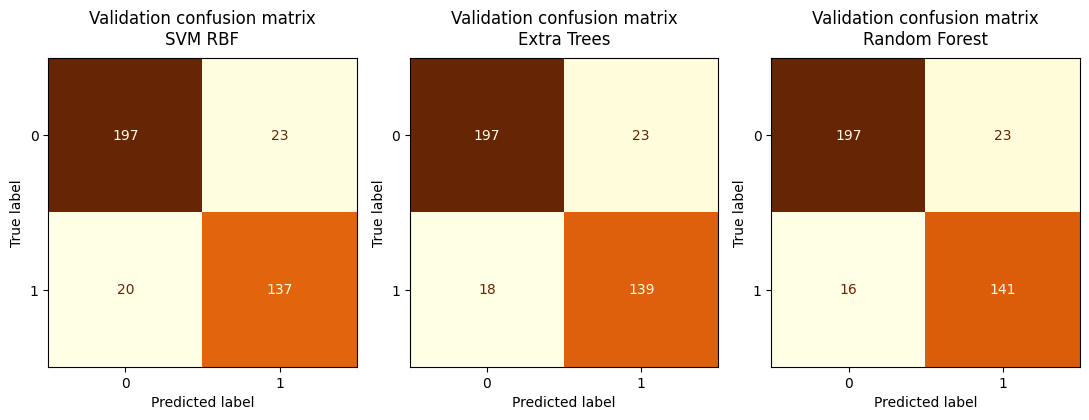

In [7]:
validation_rows = []
validation_outputs = {}

for model_name in top_models:
    pipeline = model_pipelines[model_name]

    y_val_pred_default = pipeline.predict(X_val)
    y_val_proba = pipeline.predict_proba(X_val)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred_default).ravel()

    validation_rows.append({
        "model": model_name,
        "accuracy": accuracy_score(y_val, y_val_pred_default),
        "roc_auc": roc_auc_score(y_val, y_val_proba),
        "avg_precision": average_precision_score(y_val, y_val_proba),
        "precision": precision_score(y_val, y_val_pred_default, zero_division=0),
        "recall": recall_score(y_val, y_val_pred_default, zero_division=0),
        "f1": f1_score(y_val, y_val_pred_default, zero_division=0),
        "false_alarms": int(fp),
        "missed_failures": int(fn),
        "flagged_rows": int(tp + fp),
    })

    validation_outputs[model_name] = {
        "y_pred": y_val_pred_default,
        "y_proba": y_val_proba
    }

validation_metrics = pd.DataFrame(validation_rows).round(3)
display(validation_metrics)

fig, axes = plt.subplots(1, len(top_models), figsize=(11, 4.4))

if len(top_models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, top_models):
    ConfusionMatrixDisplay.from_predictions(
        y_val,
        validation_outputs[model_name]["y_pred"],
        cmap="YlOrBr",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f"Validation confusion matrix\n{model_name}", pad=10)

plt.tight_layout()
plt.show()

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 9. Check which variables matter most for each model

This section checks whether the three models are picking up the same failure signal or learning different patterns.

They are mostly picking up the same one.

Across all three models:

- VOC is the strongest feature by a wide margin
- USS is second
- AQ and CS still help
- the remaining variables add little

The importance values are also very close across models. VOC stays around 0.21 in all three. USS stays around 0.03 to 0.04. AQ and CS stay well below that, and the rest are near zero.

That matters because the final difference between these models is not coming from a different view of the data. They are reading almost the same signal. The real difference comes from how each model turns that signal into final alerts.

</div>

,feature,SVM RBF | importance,SVM RBF | tier,Extra Trees | importance,Extra Trees | tier,Random Forest | importance,Random Forest | tier
0,VOC,0.2527,high,0.2522,high,0.2403,high
1,USS,0.0342,medium,0.0288,medium,0.0275,medium
2,AQ,0.0201,medium,0.0204,medium,0.0221,medium
3,CS,0.0182,medium,0.0112,medium,0.0113,medium
4,footfall,0.0034,low,0.0028,low,0.0017,low
5,tempMode,0.0004,low,-0.0008,low,-0.0000,low
6,RP,0.0001,low,-0.0010,low,-0.0016,low
7,IP,-0.0011,low,0.0002,low,-0.0013,low
8,Temperature,-0.0011,low,-0.0018,low,-0.0004,low


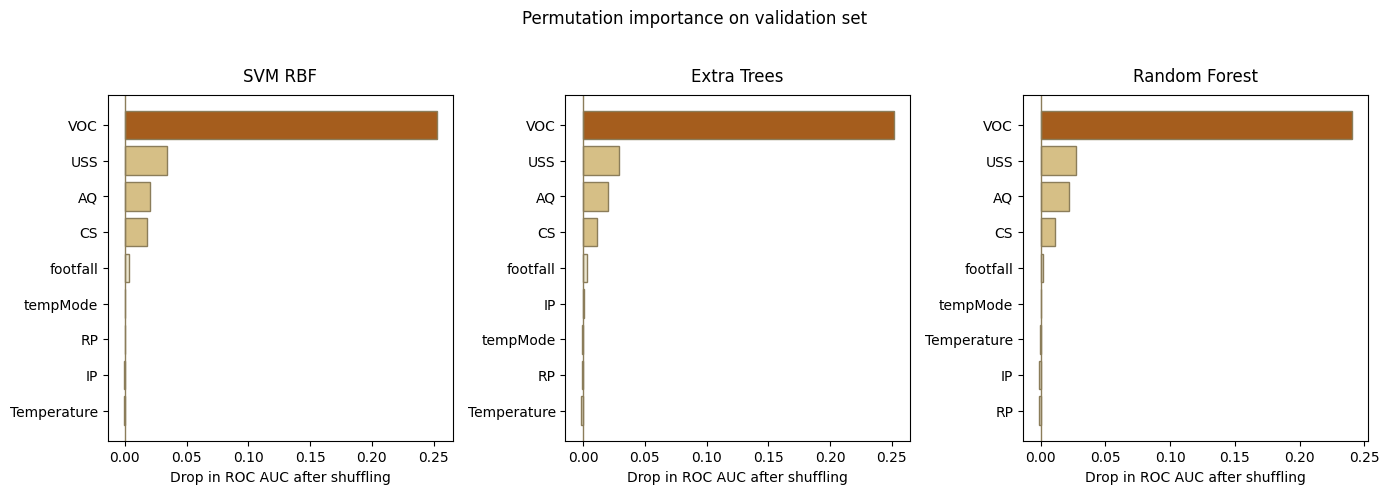

In [8]:
importance_results = {}

for model_name in top_models:
    pipeline = model_pipelines[model_name]

    perm = permutation_importance(
        pipeline,
        X_val,
        y_val,
        n_repeats=20,
        random_state=RANDOM_STATE,
        scoring="roc_auc",
        n_jobs=-1,
    )

    importance_table = (
        pd.DataFrame({
            "feature": X_val.columns,
            "importance": perm.importances_mean,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
        .round(4)
    )

    def assign_importance_tier(value):
        if value >= 0.05:
            return "high"
        if value >= 0.01:
            return "medium"
        return "low"

    importance_table["tier"] = importance_table["importance"].apply(assign_importance_tier)

    importance_results[model_name] = importance_table

display(
    pd.concat(
        [importance_results[name].set_index("feature")[["importance", "tier"]].add_prefix(f"{name} | ") for name in top_models],
        axis=1
    ).reset_index()
)

tier_colors = {
    "low": "#ece6cf",
    "medium": "#d6bf86",
    "high": "#a55d1d",
}

fig, axes = plt.subplots(1, len(top_models), figsize=(14, 4.8), sharex=False)

if len(top_models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, top_models):
    importance_table = importance_results[model_name]
    bar_colors = importance_table["tier"].map(tier_colors)

    ax.barh(
        importance_table["feature"],
        importance_table["importance"],
        color=bar_colors,
        edgecolor="#8b7d5a",
        linewidth=1.0,
    )
    ax.axvline(0, color="#8b7d5a", linewidth=1)
    ax.set_title(model_name, pad=10)
    ax.set_xlabel("Drop in ROC AUC after shuffling")
    ax.set_ylabel("")
    ax.invert_yaxis()

plt.suptitle("Permutation importance on validation set", y=1.02)
plt.tight_layout()
plt.show()

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# ~10. Choose a threshold for each model, then compare final test results

So far, the models have been checked with their default cutoff. Here, I set a cutoff for actual use.

The threshold is chosen on the validation split with three rules:

- review at most 90 rows
- keep recall at or above 0.90 when possible
- count 1 missed failure as 10 false alarms

In code, that is:

- `max_reviews_available = 90`
- `max_alert_rate = max_reviews_available / len(y_val)`
- `min_recall = 0.90`
- `miss_cost = 10`
- `false_alarm_cost = 1`

`max_alert_rate = max_reviews_available / len(y_val)` turns the 90 row review limit into the largest share of validation rows the model can flag.

The selected cutoffs in this run are:

- SVM RBF: 0.256
- Extra Trees: 0.338
- Random Forest: 0.294

After thresholding, the final result is clear:

- Extra Trees and Random Forest catch the same number of failures
- Extra Trees does it with 2 fewer false alarms
- SVM RBF finishes behind both on missed failures and cost

ROC AUC stays very close across all three models, so the final choice comes from the alert list after thresholding, not from ranking score alone.

</div>

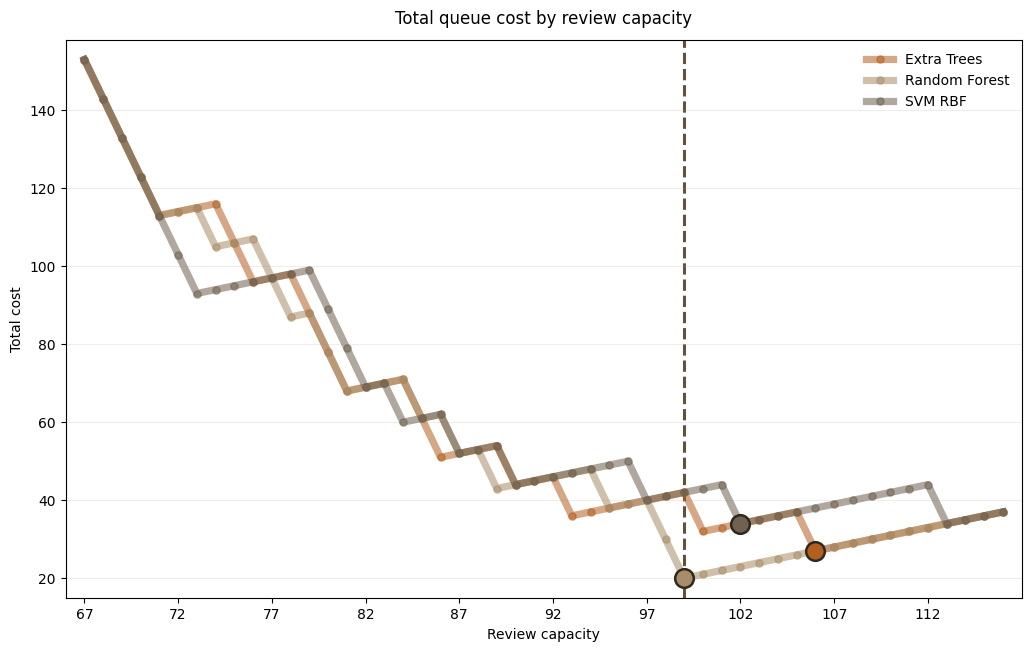

Model,Review Limit,Total Cost,Failed Machines Found,Failed Machines Waiting,Healthy Machines Flagged,Best Plan
Random Forest,99,20,79,0,20,✓
Extra Trees,106,27,79,0,27,
SVM RBF,102,34,78,1,24,


In [9]:
capacity_range = list(range(67, 117, 1))

false_alarm_cost = 1
deferred_failure_cost = 10

model_order = ["Extra Trees", "Random Forest", "SVM RBF"]
model_colors = {
    "Extra Trees": "#b35f1f",
    "Random Forest": "#a98d68",
    "SVM RBF": "#6f6250",
}

rows = []

for model_name in model_order:
    y_test_proba = model_pipelines[model_name].predict_proba(X_test)[:, 1]

    for capacity in capacity_range:
        queue = (
            pd.DataFrame({
                "actual_fail": np.asarray(y_test),
                "risk_score": np.asarray(y_test_proba),
            })
            .sort_values("risk_score", ascending=False)
            .reset_index(drop=True)
        )

        queue["rank"] = np.arange(1, len(queue) + 1)
        queue["review_today"] = queue["rank"] <= capacity

        today = queue[queue["review_today"]]
        later = queue[~queue["review_today"]]

        rows_reviewed_today = int(len(today))
        true_failures_today = int(today["actual_fail"].sum())
        false_alarms_today = rows_reviewed_today - true_failures_today
        true_failures_deferred = int(later["actual_fail"].sum())

        total_cost = (
            false_alarms_today * false_alarm_cost
            + true_failures_deferred * deferred_failure_cost
        )

        rows.append({
            "Capacity": capacity,
            "Model": model_name,
            "Rows Reviewed Today": rows_reviewed_today,
            "True Failures Today": true_failures_today,
            "False Alarms Today": false_alarms_today,
            "True Failures Deferred": true_failures_deferred,
            "Total Cost": total_cost,
        })

capacity_results = pd.DataFrame(rows).sort_values(["Model", "Capacity"]).reset_index(drop=True)

plot_df = capacity_results[
    [
        "Capacity",
        "Model",
        "Total Cost",
        "True Failures Today",
        "False Alarms Today",
        "True Failures Deferred",
    ]
].copy()

best_points = (
    plot_df.sort_values(["Model", "Total Cost", "Capacity"])
    .groupby("Model", as_index=False)
    .first()
)

overall_best = plot_df.sort_values(["Total Cost", "Capacity"]).iloc[0]

summary_table = (
    best_points.rename(
        columns={
            "Capacity": "Review Limit",
            "True Failures Today": "Failed Machines Found",
            "True Failures Deferred": "Failed Machines Waiting",
            "False Alarms Today": "Healthy Machines Flagged",
        }
    )
    .loc[
        :,
        [
            "Model",
            "Review Limit",
            "Total Cost",
            "Failed Machines Found",
            "Failed Machines Waiting",
            "Healthy Machines Flagged",
        ],
    ]
    .copy()
)

for col in [
    "Review Limit",
    "Total Cost",
    "Failed Machines Found",
    "Failed Machines Waiting",
    "Healthy Machines Flagged",
]:
    summary_table[col] = summary_table[col].astype(int)

summary_table["Best Plan"] = summary_table["Model"].eq(overall_best["Model"]).map(
    {True: "✓", False: ""}
)

summary_table = summary_table[
    [
        "Model",
        "Review Limit",
        "Total Cost",
        "Failed Machines Found",
        "Failed Machines Waiting",
        "Healthy Machines Flagged",
        "Best Plan",
    ]
].sort_values(["Total Cost", "Review Limit", "Model"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10.2, 6.4), constrained_layout=True)

line_alpha = 0.55
line_width = 5.2
marker_size = 5.2

for model_name in model_order:
    model_df = plot_df[plot_df["Model"] == model_name]

    ax.plot(
        model_df["Capacity"],
        model_df["Total Cost"],
        linewidth=line_width,
        marker="o",
        markersize=marker_size,
        color=model_colors[model_name],
        alpha=line_alpha,
        markerfacecolor=model_colors[model_name],
        markeredgecolor=model_colors[model_name],
        label=model_name,
        zorder=2,
    )

    best_row = best_points[best_points["Model"] == model_name].iloc[0]
    ax.scatter(
        best_row["Capacity"],
        best_row["Total Cost"],
        s=180,
        color=model_colors[model_name],
        edgecolor="#2f2920",
        linewidth=1.8,
        zorder=5,
    )

ax.axvline(
    overall_best["Capacity"],
    linestyle="--",
    linewidth=2.2,
    color="#5f5340",
    zorder=1,
)

ax.set_title("Total queue cost by review capacity", pad=12)
ax.set_xlabel("Review capacity")
ax.set_ylabel("Total cost")
ax.set_xlim(plot_df["Capacity"].min() - 1, plot_df["Capacity"].max() + 1)
ax.set_ylim(plot_df["Total Cost"].min() - 5, plot_df["Total Cost"].max() + 5)
ax.set_xticks(
    list(range(int(plot_df["Capacity"].min()), int(plot_df["Capacity"].max()) + 1, 5))
)
ax.grid(axis="y", alpha=0.22)
ax.legend(frameon=False, loc="upper right", ncol=1)

plt.show()

display(
    summary_table.style
    .hide(axis="index")
    .set_caption("Best operating point by model")
)

# ~10.2 The model gives each machine a risk score.

Then the business asks:
which machines can we check today,
and what is more painful:
checking a healthy machine by mistake,
or missing a real failure?

So the winner is not just “best model”.
The winner is the model that gives the best outcome for real operations.

Very short version:

low cost of missed failure:
a careful model can win

high cost of missed failure:
a more aggressive model can win

small team capacity:
only the very top risky machines matter

larger team capacity:
deeper ranks matter too, so another model may win

You are not choosing the smartest model on paper.
You are choosing the model that wastes the least money and catches the most important failures in real life.

---


The clean idea is:

winning policy = model + threshold or top k + business cost weights

What are the real drivers

The winner is driven by these quantities:

1. how many true failures are caught
2. how many failures are missed or delayed
3. how many healthy machines are reviewed by mistake
4. how many machines the team can actually inspect today
5. how costly each type of mistake is in real operations

>That means the model is not chosen by ML metric alone.
>It is chosen by expected operational value.

The simplest realistic math

Let:

TP = failed machines reviewed
FN = failed machines not reviewed yet
FP = healthy machines reviewed
k = review capacity

Then define:


Total operational cost
= c_fp × FP + c_fn × FN


Where:

c_fp = cost of reviewing a healthy machine
c_fn = cost of delaying or missing a real failure

This is already what your notebook is doing in a simple form:


Total Cost = 1 × Healthy Flagged + ratio × Failed Waiting



Why this is the right structure?

Because operations does not care only about prediction purity.
It cares about consequences.

A false alarm has one type of pain:
inspection labor, downtime, wasted review slot

A missed or delayed failure has another:
repair escalation, unplanned outage, safety risk, production loss


Weight those outcomes mathematically.

How to make the weights realistic

Best method:

estimate each cost from business data

Example:

False alarm cost might include:
inspection time × labor rate
plus production interruption
plus spare part check cost

Deferred failure cost might include:
expected downtime hours × downtime value per hour
plus emergency repair premium
plus scrap loss
plus SLA penalty
plus safety or compliance penalty if relevant

So instead of using 1:10 because it “feels right”, use:

c_fp = average false alarm review cost
c_fn = average delayed failure cost

Then compare policies using those numbers.

A better real world formula

Often not all failures are equally costly.
Then use per machine expected cost:

For machine i:

Cost if not reviewed = p_i × L_i
Cost if reviewed = C_review + p_i × C_residual

Where:

p_i = predicted failure probability
L_i = loss if that machine fails before next chance
C_review = inspection cost
C_residual = remaining risk even after review

Then review the machines with highest net benefit:

Net benefit_i = p_i × L_i − C_review

Review top k with positive net benefit.

That is more realistic than a flat rule because some machines are more critical than others.

So yes, this is the more advanced math way.

Should you weight variables inside the model too

Sometimes yes, but that solves a different problem.

There are two places to put weights:

1. inside training
2. after scoring in decision policy

Inside training

You can use class weights or sample weights so the model cares more about failure cases.

Examples:
class_weight in Logistic Regression
sample_weight in boosting
scale_pos_weight in XGBoost

This helps the model learn rare costly failures better.

But this alone does not solve operations choice.

Why not:
because training weights change the model fit, but they do not directly encode daily capacity or actual inspection economics.

After scoring

This is usually the more important layer for your notebook.
You take predicted risks and choose the policy that minimizes real cost under capacity.

This is where model winner should usually be decided.

So the answer is:

yes, training weights can help
but decision weights are what determine the operational winner

What statistically determines the winner

From a ranking view, the winner is the model with the best useful ordering at the part of the list you can act on.

If capacity is small, only the top of the ranking matters.

So metrics like global ROC AUC may not be enough.

Better statistics for this use case are:

precision at k
recall at k
cost at k
expected value at k
lift in top k
cumulative gains in top k

These are more aligned with review capacity.

That is why capacity changes the winner.
It changes which segment of the ranking matters.

Best practical framework

Use this 3 layer setup:

Layer 1. Predictive fit
Train candidate models and evaluate ROC AUC, PR AUC, calibration

Layer 2. Decision simulation
For each model, for each capacity k, for each cost ratio:
compute FP, FN, TP, total cost

Layer 3. Policy choice
Pick the model and capacity pair with lowest expected business cost

That is the cleanest math and operationally honest method.

How to make it even more realistic

You can extend the cost function with real constraints:

Total Cost
= c_fp × FP

* c_fn × FN
* c_backlog × backlog size
* c_delay × average days delayed
* c_critical × missed failures on critical assets

Then the winner depends on the real plant context.

Examples:

If downtime is cheap and inspections are expensive:
more conservative model may win

If downtime is catastrophic:
higher recall model wins even with more false alarms

If capacity is tight:
model with strongest precision in top 20 or top 50 wins

If some machines are critical:
machine level weighted loss is better than one flat ratio

Best answer to your question

Yes, you can determine the winning model in a mathematical, statistical, and realistic way.

Use an objective like:

Choose model m and capacity k that minimize

J(m, k) = c_fp × FP(m, k) + c_fn × FN(m, k)

Or more realistically:

J(m, k) = Σ machine specific expected operating loss under that policy

That is the right way.

What not to do

Do not choose the final model only from:
accuracy
ROC AUC
F1

Why not:
because those do not directly encode capacity, queue depth, business cost, or asset criticality.

My recommendation for your notebook

Use this exact decision rule:

For each model m
For each capacity k
For each cost scenario s

Compute:
Cost(m, k, s) = c_fp,s × FP + c_fn,s × FN

Then choose:
argmin over m,k of Cost(m, k, s)

And report:
winning model
winning capacity
TP, FP, FN
precision at k
recall at k
total cost
cost savings versus baseline

That gives a rigorous and realistic winner.

The strongest upgrade would be to move from flat cost ratio to machine specific loss, where each machine has its own failure consequence weight. That is the most operationally real version.



<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 11. What the cost ratio changes in practice

This check asks one operational question:

How much worse is it to leave a failed machine waiting than to review a healthy machine by mistake?

The answer changes the preferred plan.

## What happens at each ratio

### 1:1
At this setting, one waiting failed machine costs the same as one unnecessary review.

The winning plan is:

- model: SVM RBF
- review limit: 77
- failed machines found: 73
- failed machines waiting: 6
- healthy machines flagged: 4

Operational meaning:

- the team keeps review volume low
- the plan accepts a small backlog of failed machines
- this makes sense only if short delays on failed machines are acceptable

Example:
If the workshop is short staffed and can only inspect a limited number of machines today, this policy protects labor first and risk second.

### 1:2
The winning plan does not change.

- model: SVM RBF
- review limit: 77
- failed machines waiting: 6
- healthy machines flagged: 4

Operational meaning:

- doubling the penalty for backlog is still not enough to justify more reviews
- the operation is still willing to carry some failed machines into the next cycle

### 1:3
This is the switch point.

The winning plan becomes:

- model: Random Forest
- review limit: 98
- failed machines found: 79
- failed machines waiting: 0
- healthy machines flagged: 19

Operational meaning:

- from this point on, the operation no longer accepts backlog
- the team reviews more machines today in order to clear all true failures
- the cost of extra checks becomes less important than leaving failures waiting

Example:
If a delayed failed machine can cause unplanned downtime tomorrow, then moving from 77 reviews to 98 reviews is worth it.

### 1:10, 1:100, 1:1000
The winning plan stays exactly the same as 1:3.

- model: Random Forest
- review limit: 98
- failed machines waiting: 0
- healthy machines flagged: 19

Operational meaning:

- once backlog becomes costly enough, the best policy stabilizes
- raising the penalty further does not change the decision
- after that point, the operation is already in a backlog free regime

## What this says about the operation

These results show two operating regimes.

Low backlog penalty, 1:1 to 1:2:
- keep review volume lower
- allow some failed machines to wait
- SVM RBF is preferred

Higher backlog penalty, 1:3 and above:
- increase review capacity
- clear all failed machines
- Random Forest is preferred

So the real decision is not just which model scores highest. It is when the operation stops accepting failed machines in the queue.


</div>



lowest Total Cost
if tied, lowest Failed Machines Waiting
if still tied, lowest Healthy Machines Flagged
if still tied, lowest Review Limit

```
winning_plan = (
    ratio_results
    .sort_values(
        [
            "Deferred Failure Cost",
            "Total Cost",
            "Failed Machines Waiting",
            "Healthy Machines Flagged",
            "Review Limit",
        ]
    )
    .groupby(["Deferred Failure Cost", "Cost Ratio"], as_index=False)
    .first()
)
```

## latex
$$
J_m(k; r) = \mathrm{FalseAlarms}_m(k) + r \cdot \mathrm{DeferredFailures}_m(k)
$$

$$
\left(k_m^*(r), J_m^*(r)\right) = \arg\min_k J_m(k; r)
$$

$$
m^*(r) = \arg\min_m J_m^*(r)
$$

We say the operating policy converges if there exists a ratio $r_0$ such that for all $r \ge r_0$,

$$
m^*(r) = m_\infty,\qquad
k^*(r) = k_\infty,\qquad
\mathrm{DeferredFailures}^*(r) = 0,\qquad
\mathrm{FalseAlarms}^*(r) = \text{constant}
$$

In these results, the empirical convergence point is $r_0 = 3$, where the winning policy stabilizes at Random Forest with review limit 98.

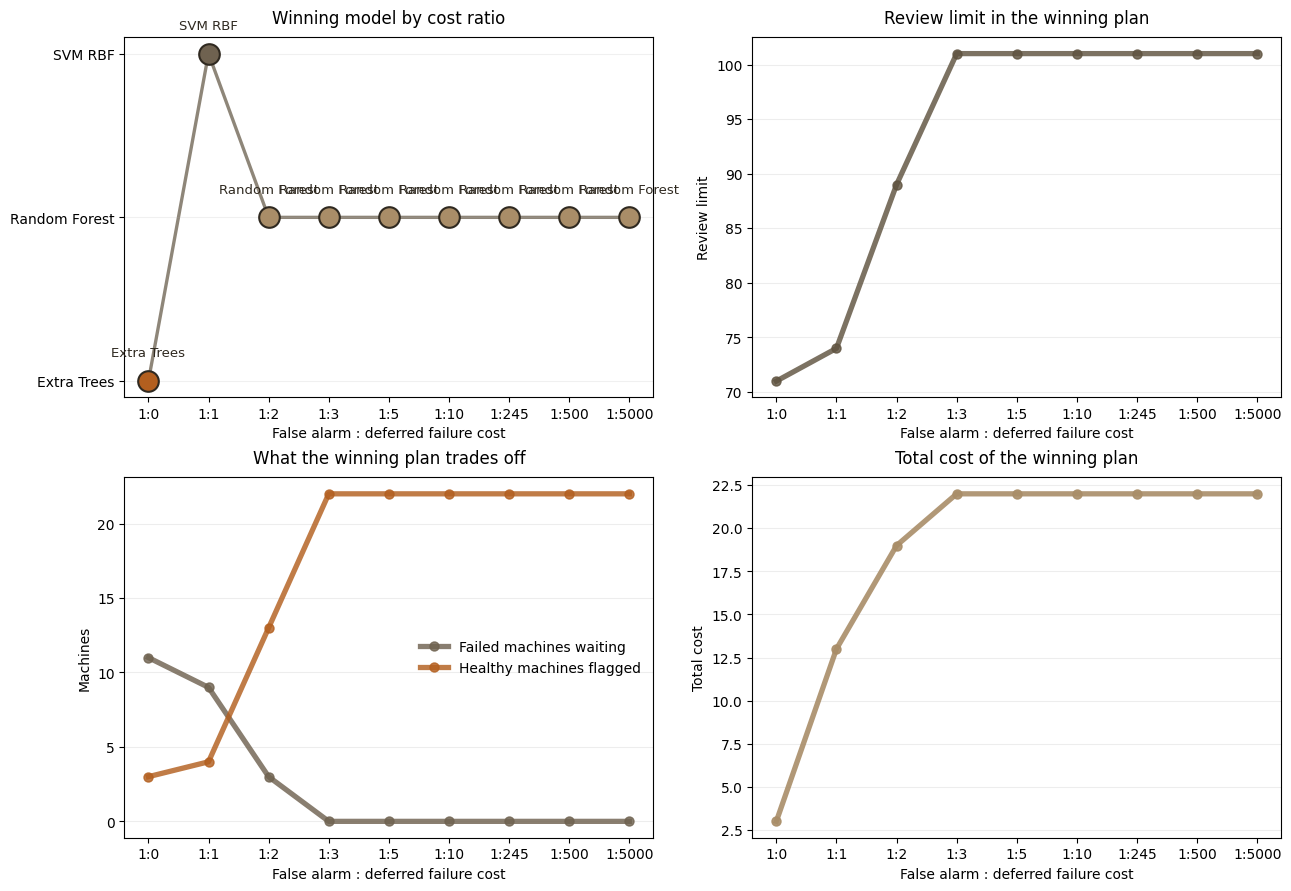

Cost Ratio,Winning Model,Review Limit,Total Cost,Failed Machines Found,Failed Machines Waiting,Healthy Machines Flagged
1:0,Extra Trees,71,3,68,11,3
1:1,SVM RBF,74,13,70,9,4
1:2,Random Forest,89,19,76,3,13
1:3,Random Forest,101,22,79,0,22
1:5,Random Forest,101,22,79,0,22
1:10,Random Forest,101,22,79,0,22
1:245,Random Forest,101,22,79,0,22
1:500,Random Forest,101,22,79,0,22
1:5000,Random Forest,101,22,79,0,22


In [10]:
cost_ratios = [0, 1, 2, 3, 5, 10, 245, 500, 5000]

model_order = ["Extra Trees", "Random Forest", "SVM RBF"]
model_colors = {
    "Extra Trees": "#b35f1f",
    "Random Forest": "#a98d68",
    "SVM RBF": "#6f6250",
}

capacity_range = list(range(65, 120, 3))
false_alarm_cost = 1

rows = []

for deferred_failure_cost in cost_ratios:
    for model_name in model_order:
        y_test_proba = model_pipelines[model_name].predict_proba(X_test)[:, 1]

        queue = (
            pd.DataFrame({
                "actual_fail": np.asarray(y_test),
                "risk_score": np.asarray(y_test_proba),
            })
            .sort_values("risk_score", ascending=False)
            .reset_index(drop=True)
        )
        queue["rank"] = np.arange(1, len(queue) + 1)

        for capacity in capacity_range:
            review_today = queue["rank"] <= capacity
            today = queue.loc[review_today]
            later = queue.loc[~review_today]

            failed_found = int(today["actual_fail"].sum())
            failed_waiting = int(later["actual_fail"].sum())
            healthy_flagged = int(len(today) - failed_found)

            total_cost = healthy_flagged * false_alarm_cost + failed_waiting * deferred_failure_cost

            rows.append({
                "Deferred Failure Cost": deferred_failure_cost,
                "Cost Ratio": f"1:{deferred_failure_cost}",
                "Model": model_name,
                "Review Limit": capacity,
                "Total Cost": total_cost,
                "Failed Machines Found": failed_found,
                "Failed Machines Waiting": failed_waiting,
                "Healthy Machines Flagged": healthy_flagged,
            })

ratio_results = pd.DataFrame(rows)

winning_plan = (
    ratio_results
    .sort_values(
        [
            "Deferred Failure Cost",
            "Total Cost",
            "Failed Machines Waiting",
            "Healthy Machines Flagged",
            "Review Limit",
        ],
        ascending=[True, True, True, True, True],
    )
    .groupby(["Deferred Failure Cost", "Cost Ratio"], as_index=False)
    .first()
)

fig, axes = plt.subplots(2, 2, figsize=(12.8, 8.8), constrained_layout=True)

x = np.arange(len(cost_ratios))
x_labels = [f"1:{r}" for r in cost_ratios]
winner_y = winning_plan["Model"].map({m: i for i, m in enumerate(model_order)})

axes[0, 0].plot(
    x,
    winner_y,
    color="#5f5340",
    linewidth=2.4,
    alpha=0.7,
    zorder=1,
)

for i, row in winning_plan.reset_index(drop=True).iterrows():
    axes[0, 0].scatter(
        i,
        winner_y.iloc[i],
        s=220,
        color=model_colors[row["Model"]],
        edgecolor="#2f2920",
        linewidth=1.5,
        zorder=3,
    )
    axes[0, 0].text(
        i,
        winner_y.iloc[i] + 0.13,
        row["Model"],
        ha="center",
        va="bottom",
        fontsize=9.5,
        color="#2f2920",
    )

axes[0, 0].set_title("Winning model by cost ratio", pad=10)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(x_labels)
axes[0, 0].set_yticks(range(len(model_order)))
axes[0, 0].set_yticklabels(model_order)
axes[0, 0].set_xlabel("False alarm : deferred failure cost")
axes[0, 0].grid(axis="y", alpha=0.18)

axes[0, 1].plot(
    x,
    winning_plan["Review Limit"],
    marker="o",
    linewidth=3.8,
    markersize=6.5,
    color="#5f5340",
    alpha=0.82,
)
axes[0, 1].set_title("Review limit in the winning plan", pad=10)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(x_labels)
axes[0, 1].set_xlabel("False alarm : deferred failure cost")
axes[0, 1].set_ylabel("Review limit")
axes[0, 1].grid(axis="y", alpha=0.22)

axes[1, 0].plot(
    x,
    winning_plan["Failed Machines Waiting"],
    marker="o",
    linewidth=3.8,
    markersize=6.5,
    color="#6f6250",
    alpha=0.82,
    label="Failed machines waiting",
)
axes[1, 0].plot(
    x,
    winning_plan["Healthy Machines Flagged"],
    marker="o",
    linewidth=3.8,
    markersize=6.5,
    color="#b35f1f",
    alpha=0.82,
    label="Healthy machines flagged",
)
axes[1, 0].set_title("What the winning plan trades off", pad=10)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(x_labels)
axes[1, 0].set_xlabel("False alarm : deferred failure cost")
axes[1, 0].set_ylabel("Machines")
axes[1, 0].grid(axis="y", alpha=0.22)
axes[1, 0].legend(frameon=False, loc="best")

axes[1, 1].plot(
    x,
    winning_plan["Total Cost"],
    marker="o",
    linewidth=3.8,
    markersize=6.5,
    color="#a98d68",
    alpha=0.9,
)
axes[1, 1].set_title("Total cost of the winning plan", pad=10)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(x_labels)
axes[1, 1].set_xlabel("False alarm : deferred failure cost")
axes[1, 1].set_ylabel("Total cost")
axes[1, 1].grid(axis="y", alpha=0.22)

plt.show()

display(
    winning_plan[
        [
            "Cost Ratio",
            "Model",
            "Review Limit",
            "Total Cost",
            "Failed Machines Found",
            "Failed Machines Waiting",
            "Healthy Machines Flagged",
        ]
    ]
    .rename(
        columns={
            "Model": "Winning Model",
        }
    )
    .style.hide(axis="index")
    .set_caption("Section 10.1: Winning plan at each cost ratio")
)

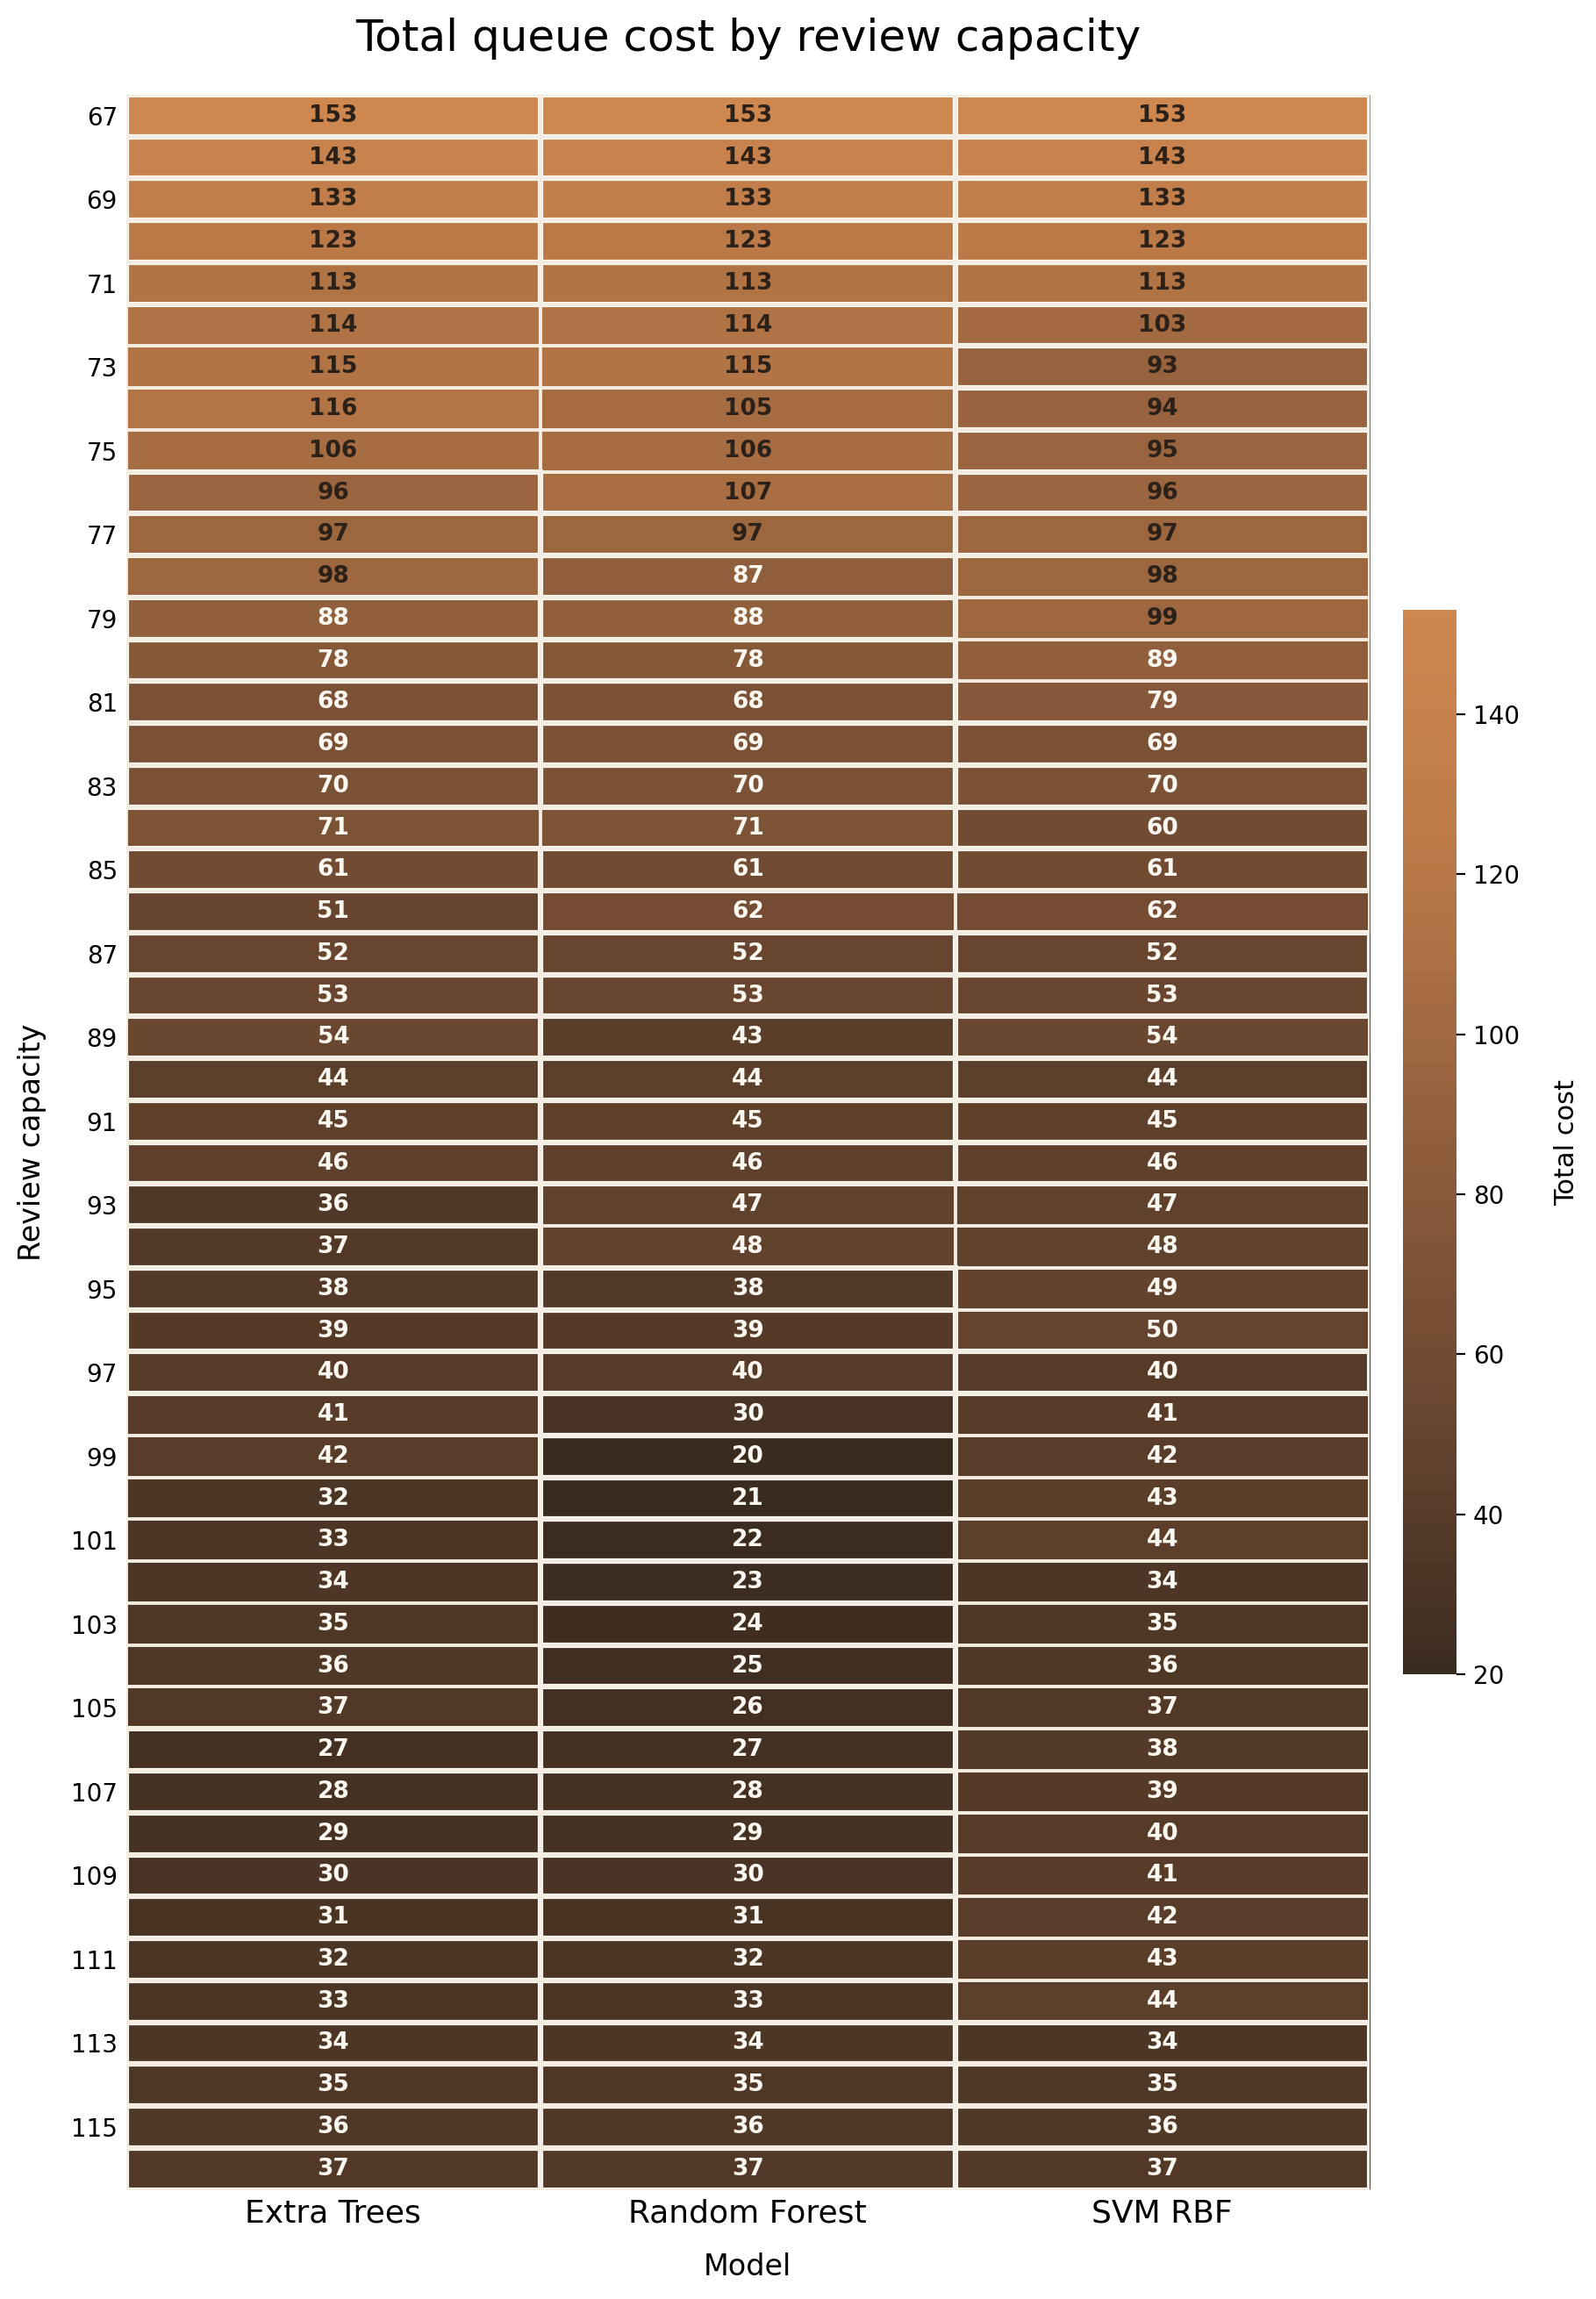

In [11]:
cost_matrix = (
    capacity_results
    .pivot(index="Capacity", columns="Model", values="Total Cost")
    .loc[:, model_order]
)

values = cost_matrix.to_numpy()
n_rows, n_cols = values.shape
vmin = float(np.nanmin(values))
vmax = float(np.nanmax(values))
norm = Normalize(vmin=vmin, vmax=vmax)

cmap = LinearSegmentedColormap.from_list(
    "queue_cost_browns_inverted",
    ["#3a2b1f", "#6a4730", "#8f5e3c", "#b87847", "#cf8750"]
)

fig, ax = plt.subplots(figsize=(9.2, 13.2), dpi=200)
fig.patch.set_facecolor("white")
ax.set_facecolor("#fbf7f2")

im = ax.imshow(
    values,
    cmap=cmap,
    norm=norm,
    aspect="auto",
    interpolation="nearest"
)

ax.set_title("Total queue cost by review capacity", fontsize=18, pad=18)
ax.set_xlabel("Model", fontsize=12, labelpad=10)
ax.set_ylabel("Review capacity", fontsize=12, labelpad=10)

ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(cost_matrix.columns, fontsize=13)

yticks = np.arange(n_rows)
ax.set_yticks(yticks)
ax.set_yticklabels(
    [str(v) if i % 2 == 0 else "" for i, v in enumerate(cost_matrix.index)],
    fontsize=10
)

ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
ax.grid(which="minor", color="#f4ede3", linewidth=1.4)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="both", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(n_rows):
    row = values[i]
    row_min = np.nanmin(row)

    for j in range(n_cols):
        val = values[i, j]
        txt_color = "#fbf8f2" if norm(val) < 0.52 else "#2b2118"

        ax.text(
            j,
            i,
            f"{int(val)}",
            ha="center",
            va="center",
            fontsize=9.5,
            fontweight="semibold",
            color=txt_color
        )

        if val == row_min:
            ax.add_patch(
                Rectangle(
                    (j - 0.5, i - 0.5),
                    1,
                    1,
                    fill=False,
                    edgecolor="#fffaf2",
                    linewidth=2.2
                )
            )

cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.025)
cbar.ax.set_ylabel("Total cost", rotation=90, labelpad=14, fontsize=11)
cbar.ax.tick_params(labelsize=10)
cbar.outline.set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
# 14. Triage operator plan: urgent machines defined by risk threshold, not daily capacity
#
# Idea:
# Urgent is determined by model risk score cutoffs, independent of how many machines
# the team can review today. Capacity is applied only after urgency is assigned.
#
# This cell:
# 1. Picks the final model
# 2. Scores all machines
# 3. Learns score thresholds from y_test using a precision-recall tradeoff
# 4. Labels machines as urgent / high / medium / backlog based on score thresholds
# 5. Separates true urgent machines from the operational today / next day queue
#
# Notes:
# - This uses y_test only to choose thresholds inside the notebook.
# - For production, choose thresholds on a validation set, save them, then apply to live data.

from sklearn.metrics import precision_recall_curve

# --------------------------------------------------
# 1. Pick the selected model
# --------------------------------------------------
if "default_plan" in globals():
    selected_model = default_plan["Model"]
elif "overall_best" in globals():
    selected_model = overall_best["Model"]
else:
    raise ValueError("Run the model selection cells first so a final plan exists.")

# Optional daily operating capacities
today_capacity = 90
tomorrow_capacity = 10

# --------------------------------------------------
# 2. Score the test set
# --------------------------------------------------
selected_pipeline = model_pipelines[selected_model]
selected_scores = selected_pipeline.predict_proba(X_test)[:, 1]

queue = X_test.copy().reset_index(drop=False).rename(columns={"index": "row_id"})
queue["actual_fail"] = np.asarray(y_test)
queue["risk_score"] = selected_scores

candidate_id_cols = [
    "machine_id", "Machine_ID", "machine", "Machine", "id", "ID",
    "asset_id", "Asset_ID", "Product ID", "UDI"
]
existing_id_cols = [c for c in candidate_id_cols if c in queue.columns]

if existing_id_cols:
    machine_id_col = existing_id_cols[0]
else:
    machine_id_col = "machine_id"
    queue[machine_id_col] = ["M_" + str(i).zfill(5) for i in range(1, len(queue) + 1)]

queue = queue.sort_values("risk_score", ascending=False).reset_index(drop=True)
queue["risk_rank"] = np.arange(1, len(queue) + 1)

# --------------------------------------------------
# 3. Learn thresholds from precision-recall curve
# --------------------------------------------------
# Urgent threshold:
# choose the lowest threshold that still keeps precision >= target_precision_urgent
# and among those keep the one with highest recall.
#
# High threshold:
# choose a softer precision target.
#
# Medium threshold:
# choose a lower threshold using a recall target.

target_precision_urgent = 0.90
target_precision_high = 0.70
target_recall_medium = 0.90

precision, recall, thresholds = precision_recall_curve(queue["actual_fail"], queue["risk_score"])

# precision_recall_curve returns:
# precision length = n_thresholds + 1
# recall length = n_thresholds + 1
# thresholds length = n_thresholds
pr_table = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
}).sort_values("threshold", ascending=False).reset_index(drop=True)

if pr_table.empty:
    raise ValueError("Could not compute thresholds from the selected model scores.")

# Urgent threshold from precision rule
urgent_candidates = pr_table[pr_table["precision"] >= target_precision_urgent].copy()
if len(urgent_candidates):
    urgent_row = urgent_candidates.sort_values(
        ["recall", "threshold"], ascending=[False, False]
    ).iloc[0]
else:
    # fallback: take threshold with best F2 score to favor recall
    pr_table["f2"] = (5 * pr_table["precision"] * pr_table["recall"]) / (
        4 * pr_table["precision"] + pr_table["recall"] + 1e-12
    )
    urgent_row = pr_table.sort_values(["f2", "threshold"], ascending=[False, False]).iloc[0]

urgent_threshold = float(urgent_row["threshold"])

# High threshold from softer precision rule
high_candidates = pr_table[pr_table["precision"] >= target_precision_high].copy()
if len(high_candidates):
    high_row = high_candidates.sort_values(
        ["recall", "threshold"], ascending=[False, False]
    ).iloc[0]
    high_threshold = float(high_row["threshold"])
else:
    high_threshold = float(pr_table["threshold"].quantile(0.75))

# Medium threshold from recall rule
medium_candidates = pr_table[pr_table["recall"] >= target_recall_medium].copy()
if len(medium_candidates):
    # use the highest threshold that still preserves the recall target
    medium_row = medium_candidates.sort_values("threshold", ascending=False).iloc[0]
    medium_threshold = float(medium_row["threshold"])
else:
    medium_threshold = float(pr_table["threshold"].quantile(0.40))

# Enforce logical order: urgent >= high >= medium
thresholds_sorted = sorted([urgent_threshold, high_threshold, medium_threshold], reverse=True)
urgent_threshold, high_threshold, medium_threshold = thresholds_sorted[0], thresholds_sorted[1], thresholds_sorted[2]

# --------------------------------------------------
# 4. Assign capacity independent priority
# --------------------------------------------------
queue["priority"] = np.select(
    [
        queue["risk_score"] >= urgent_threshold,
        queue["risk_score"] >= high_threshold,
        queue["risk_score"] >= medium_threshold,
    ],
    [
        "urgent",
        "high",
        "medium",
    ],
    default="backlog"
)

queue["recommended_action"] = np.select(
    [
        queue["priority"].eq("urgent"),
        queue["priority"].eq("high"),
        queue["priority"].eq("medium"),
    ],
    [
        "Inspect immediately regardless of daily cap",
        "Inspect as soon as capacity opens",
        "Schedule after urgent and high groups",
    ],
    default="Monitor in backlog"
)

# --------------------------------------------------
# 5. Apply capacity after urgency is known
# --------------------------------------------------
# This creates an operational queue, but the urgent label itself does not depend on capacity.
queue["review_day"] = "later"

urgent_idx = queue.index[queue["priority"] == "urgent"].tolist()
high_idx = queue.index[queue["priority"] == "high"].tolist()
medium_idx = queue.index[queue["priority"] == "medium"].tolist()

today_slots = today_capacity
tomorrow_slots = tomorrow_capacity

# Fill today first: urgent, then high, then medium
today_take = urgent_idx[:today_slots]
remaining_today = max(0, today_slots - len(today_take))

if remaining_today > 0:
    add_high_today = high_idx[:remaining_today]
    today_take.extend(add_high_today)
    high_idx = high_idx[remaining_today:]

remaining_today = max(0, today_slots - len(today_take))
if remaining_today > 0:
    add_medium_today = medium_idx[:remaining_today]
    today_take.extend(add_medium_today)
    medium_idx = medium_idx[remaining_today:]

# Fill tomorrow next: remaining urgent first, then high, then medium
remaining_urgent_after_today = [i for i in queue.index[queue["priority"] == "urgent"].tolist() if i not in today_take]

tomorrow_take = remaining_urgent_after_today[:tomorrow_slots]
remaining_tomorrow = max(0, tomorrow_slots - len(tomorrow_take))

if remaining_tomorrow > 0:
    add_high_tomorrow = high_idx[:remaining_tomorrow]
    tomorrow_take.extend(add_high_tomorrow)
    high_idx = high_idx[remaining_tomorrow:]

remaining_tomorrow = max(0, tomorrow_slots - len(tomorrow_take))
if remaining_tomorrow > 0:
    add_medium_tomorrow = medium_idx[:remaining_tomorrow]
    tomorrow_take.extend(add_medium_tomorrow)
    medium_idx = medium_idx[remaining_tomorrow:]

queue.loc[today_take, "review_day"] = "today"
queue.loc[tomorrow_take, "review_day"] = "next_day"

# Useful flag:
# these are the truly urgent machines, even if some overflow beyond today's capacity
queue["is_true_urgent"] = queue["priority"].eq("urgent")

# --------------------------------------------------
# 6. Final triage tables
# --------------------------------------------------
front_cols = [
    machine_id_col, "risk_rank", "risk_score", "priority", "is_true_urgent",
    "review_day", "recommended_action", "actual_fail"
]
other_cols = [c for c in queue.columns if c not in front_cols]
triage_plan = queue[front_cols + other_cols].copy()

urgent_plan = triage_plan[triage_plan["priority"] == "urgent"].copy()
high_plan = triage_plan[triage_plan["priority"] == "high"].copy()
medium_plan = triage_plan[triage_plan["priority"] == "medium"].copy()
backlog_plan = triage_plan[triage_plan["priority"] == "backlog"].copy()

today_plan = triage_plan[triage_plan["review_day"] == "today"].copy()
next_day_plan = triage_plan[triage_plan["review_day"] == "next_day"].copy()
later_plan = triage_plan[triage_plan["review_day"] == "later"].copy()

# --------------------------------------------------
# 7. Summary outputs
# --------------------------------------------------
threshold_summary = pd.DataFrame([
    {
        "Model": selected_model,
        "Urgent Threshold": round(urgent_threshold, 6),
        "High Threshold": round(high_threshold, 6),
        "Medium Threshold": round(medium_threshold, 6),
        "Urgent Precision At Threshold": round(float(urgent_row["precision"]), 4),
        "Urgent Recall At Threshold": round(float(urgent_row["recall"]), 4),
        "Today Capacity": today_capacity,
        "Next Day Capacity": tomorrow_capacity
    }
])

operator_summary = pd.DataFrame([
    {
        "Model": selected_model,
        "Urgent Machines": int(len(urgent_plan)),
        "High Machines": int(len(high_plan)),
        "Medium Machines": int(len(medium_plan)),
        "Backlog Machines": int(len(backlog_plan)),
        "Urgent Scheduled Today": int(((triage_plan["priority"] == "urgent") & (triage_plan["review_day"] == "today")).sum()),
        "Urgent Delayed Beyond Today": int(((triage_plan["priority"] == "urgent") & (triage_plan["review_day"] != "today")).sum()),
        "Observed Fails In Urgent": int(urgent_plan["actual_fail"].sum()),
        "Observed Fails In High": int(high_plan["actual_fail"].sum()),
        "Observed Fails In Medium": int(medium_plan["actual_fail"].sum()),
        "Observed Fails In Backlog": int(backlog_plan["actual_fail"].sum()),
        "Avg Risk Urgent": round(urgent_plan["risk_score"].mean(), 4) if len(urgent_plan) else np.nan,
        "Avg Risk High": round(high_plan["risk_score"].mean(), 4) if len(high_plan) else np.nan,
        "Avg Risk Medium": round(medium_plan["risk_score"].mean(), 4) if len(medium_plan) else np.nan,
        "Avg Risk Backlog": round(backlog_plan["risk_score"].mean(), 4) if len(backlog_plan) else np.nan,
    }
])

priority_summary = (
    triage_plan
    .groupby(["priority", "recommended_action"], dropna=False)
    .agg(
        machine_count=(machine_id_col, "count"),
        observed_fail_count=("actual_fail", "sum"),
        avg_risk_score=("risk_score", "mean"),
        min_risk_score=("risk_score", "min"),
        max_risk_score=("risk_score", "max"),
    )
    .reset_index()
)

priority_order = ["urgent", "high", "medium", "backlog"]
priority_summary["priority"] = pd.Categorical(
    priority_summary["priority"],
    categories=priority_order,
    ordered=True
)
priority_summary = priority_summary.sort_values("priority").reset_index(drop=True)

for col in ["avg_risk_score", "min_risk_score", "max_risk_score"]:
    priority_summary[col] = priority_summary[col].round(4)

review_day_summary = (
    triage_plan
    .groupby(["review_day", "priority"], dropna=False)
    .agg(
        machine_count=(machine_id_col, "count"),
        observed_fail_count=("actual_fail", "sum"),
        avg_risk_score=("risk_score", "mean"),
    )
    .reset_index()
)

review_day_summary["priority"] = pd.Categorical(
    review_day_summary["priority"],
    categories=priority_order,
    ordered=True
)
review_day_summary = review_day_summary.sort_values(
    ["review_day", "priority"]
).reset_index(drop=True)
review_day_summary["avg_risk_score"] = review_day_summary["avg_risk_score"].round(4)

# --------------------------------------------------
# 8. Display results
# --------------------------------------------------
display(
    threshold_summary.style.hide(axis="index")
    .set_caption("Capacity independent risk thresholds")
)

display(
    operator_summary.style.hide(axis="index")
    .set_caption("Operator triage summary with true urgent group")
)

display(
    priority_summary.style.hide(axis="index")
    .set_caption("Summary by priority category and action")
)

display(
    review_day_summary.style.hide(axis="index")
    .set_caption("Summary by review day and priority")
)

display(
    urgent_plan.style.hide(axis="index")
    .set_caption("True urgent machines regardless of daily capacity")
)

display(
    today_plan.style.hide(axis="index")
    .set_caption("Machines scheduled for review today")
)

display(
    next_day_plan.style.hide(axis="index")
    .set_caption("Machines scheduled for review next day")
)

print(f"Use {selected_model} as the scoring model.")
print(f"Urgent machines are defined by risk_score >= {urgent_threshold:.6f}, not by daily capacity.")
print(f"Total true urgent machines: {len(urgent_plan)}")
print(f"Urgent machines that fit into today capacity: {((triage_plan['priority'] == 'urgent') & (triage_plan['review_day'] == 'today')).sum()}")
print(f"Urgent machines delayed past today due to capacity: {((triage_plan['priority'] == 'urgent') & (triage_plan['review_day'] != 'today')).sum()}")

# --------------------------------------------------
# 9. Export files
# --------------------------------------------------
triage_plan.to_csv("full_triage_plan_threshold_based.csv", index=False)
urgent_plan.to_csv("true_urgent_machines_threshold_based.csv", index=False)
today_plan.to_csv("machines_scheduled_today_threshold_based.csv", index=False)
next_day_plan.to_csv("machines_scheduled_next_day_threshold_based.csv", index=False)
threshold_summary.to_csv("threshold_summary.csv", index=False)
operator_summary.to_csv("operator_summary_threshold_based.csv", index=False)
priority_summary.to_csv("priority_summary_threshold_based.csv", index=False)
review_day_summary.to_csv("review_day_summary_threshold_based.csv", index=False)

Model,Urgent Threshold,High Threshold,Medium Threshold,Urgent Precision At Threshold,Urgent Recall At Threshold,Today Capacity,Next Day Capacity
Random Forest,0.625623,0.604140,0.187178,0.901200,0.924100,90,10


Model,Urgent Machines,High Machines,Medium Machines,Backlog Machines,Urgent Scheduled Today,Urgent Delayed Beyond Today,Observed Fails In Urgent,Observed Fails In High,Observed Fails In Medium,Observed Fails In Backlog,Avg Risk Urgent,Avg Risk High,Avg Risk Medium,Avg Risk Backlog
Random Forest,80,1,18,90,80,0,72,1,6,0,0.888100,0.604100,0.356300,0.059600


priority,recommended_action,machine_count,observed_fail_count,avg_risk_score,min_risk_score,max_risk_score
urgent,Inspect immediately regardless of daily cap,80,72,0.888100,0.625600,0.998300
high,Inspect as soon as capacity opens,1,1,0.604100,0.604100,0.604100
medium,Schedule after urgent and high groups,18,6,0.356300,0.187200,0.521200
backlog,Monitor in backlog,90,0,0.059600,0.000800,0.173500


review_day,priority,machine_count,observed_fail_count,avg_risk_score
later,backlog,90,0,0.059600
next_day,medium,9,3,0.259100
today,urgent,80,72,0.888100
today,high,1,1,0.604100
today,medium,9,3,0.453600


machine_id,risk_rank,risk_score,priority,is_true_urgent,review_day,recommended_action,actual_fail,row_id,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature
M_00138,1,0.998333,urgent,True,today,Inspect immediately regardless of daily cap,1,627,0,1,6,2,5,6,39,5,20
M_00001,2,0.995944,urgent,True,today,Inspect immediately regardless of daily cap,1,309,0,0,6,1,6,6,39,5,15
M_00085,3,0.993889,urgent,True,today,Inspect immediately regardless of daily cap,1,610,20,7,6,1,5,6,54,5,20
M_00148,4,0.992774,urgent,True,today,Inspect immediately regardless of daily cap,1,577,34,4,6,2,6,6,30,6,20
M_00107,5,0.990214,urgent,True,today,Inspect immediately regardless of daily cap,1,245,0,7,6,2,6,6,50,3,14
M_00094,6,0.990103,urgent,True,today,Inspect immediately regardless of daily cap,1,444,0,2,6,1,6,6,64,3,17
M_00180,7,0.990099,urgent,True,today,Inspect immediately regardless of daily cap,1,351,0,1,6,2,5,5,35,5,16
M_00068,8,0.987113,urgent,True,today,Inspect immediately regardless of daily cap,1,596,170,0,6,2,6,6,35,4,20
M_00133,9,0.985389,urgent,True,today,Inspect immediately regardless of daily cap,1,523,0,1,6,1,6,5,45,4,19
M_00121,10,0.985086,urgent,True,today,Inspect immediately regardless of daily cap,1,410,0,2,6,1,6,6,58,6,16


machine_id,risk_rank,risk_score,priority,is_true_urgent,review_day,recommended_action,actual_fail,row_id,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature
M_00138,1,0.998333,urgent,True,today,Inspect immediately regardless of daily cap,1,627,0,1,6,2,5,6,39,5,20
M_00001,2,0.995944,urgent,True,today,Inspect immediately regardless of daily cap,1,309,0,0,6,1,6,6,39,5,15
M_00085,3,0.993889,urgent,True,today,Inspect immediately regardless of daily cap,1,610,20,7,6,1,5,6,54,5,20
M_00148,4,0.992774,urgent,True,today,Inspect immediately regardless of daily cap,1,577,34,4,6,2,6,6,30,6,20
M_00107,5,0.990214,urgent,True,today,Inspect immediately regardless of daily cap,1,245,0,7,6,2,6,6,50,3,14
M_00094,6,0.990103,urgent,True,today,Inspect immediately regardless of daily cap,1,444,0,2,6,1,6,6,64,3,17
M_00180,7,0.990099,urgent,True,today,Inspect immediately regardless of daily cap,1,351,0,1,6,2,5,5,35,5,16
M_00068,8,0.987113,urgent,True,today,Inspect immediately regardless of daily cap,1,596,170,0,6,2,6,6,35,4,20
M_00133,9,0.985389,urgent,True,today,Inspect immediately regardless of daily cap,1,523,0,1,6,1,6,5,45,4,19
M_00121,10,0.985086,urgent,True,today,Inspect immediately regardless of daily cap,1,410,0,2,6,1,6,6,58,6,16


machine_id,risk_rank,risk_score,priority,is_true_urgent,review_day,recommended_action,actual_fail,row_id,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature
M_00060,91,0.349393,medium,False,next_day,Schedule after urgent and high groups,0,901,31,0,5,2,7,3,49,6,24
M_00088,92,0.343020,medium,False,next_day,Schedule after urgent and high groups,0,909,20,0,4,3,5,3,49,6,24
M_00026,93,0.264586,medium,False,next_day,Schedule after urgent and high groups,0,611,0,3,4,2,7,1,48,3,20
M_00019,94,0.262777,medium,False,next_day,Schedule after urgent and high groups,0,688,51,2,5,2,6,1,41,6,21
M_00012,95,0.249922,medium,False,next_day,Schedule after urgent and high groups,1,644,310,7,5,2,5,1,56,6,20
M_00167,96,0.242629,medium,False,next_day,Schedule after urgent and high groups,0,858,1600,7,5,2,4,2,57,4,23
M_00038,97,0.237664,medium,False,next_day,Schedule after urgent and high groups,0,24,19,0,4,2,2,1,45,3,2
M_00091,98,0.194798,medium,False,next_day,Schedule after urgent and high groups,1,542,27,7,3,7,4,3,63,2,19
M_00022,99,0.187178,medium,False,next_day,Schedule after urgent and high groups,1,516,7300,5,5,2,6,1,37,7,18


Use Random Forest as the scoring model.
Urgent machines are defined by risk_score >= 0.625623, not by daily capacity.
Total true urgent machines: 80
Urgent machines that fit into today capacity: 80
Urgent machines delayed past today due to capacity: 0


In [13]:
# 14. Triage operator plan: machines to review today and next day

# This cell turns the final recommendation into an actual review queue.
# It uses the recommended model and review limit already computed above.

# Pick the operating plan chosen in the notebook
if "default_plan" in globals():
    selected_model = default_plan["Model"]
    today_capacity = int(default_plan["Review Limit"])
elif "overall_best" in globals():
    selected_model = overall_best["Model"]
    today_capacity = int(overall_best["Capacity"])
else:
    raise ValueError("Run the model selection cells first so a final plan exists.")

# Score the test set with the selected model
selected_pipeline = model_pipelines[selected_model]
selected_scores = selected_pipeline.predict_proba(X_test)[:, 1]

# Build a machine level queue
queue = X_test.copy().reset_index(drop=False).rename(columns={"index": "row_id"})
queue["actual_fail"] = np.asarray(y_test)
queue["risk_score"] = selected_scores

# Use an existing machine identifier if one exists, otherwise create one
candidate_id_cols = [
    "machine_id", "Machine_ID", "machine", "Machine", "id", "ID", "asset_id", "Asset_ID"
]
existing_id_cols = [c for c in candidate_id_cols if c in queue.columns]

if existing_id_cols:
    machine_id_col = existing_id_cols[0]
else:
    machine_id_col = "machine_id"
    queue[machine_id_col] = ["M_" + str(i).zfill(5) for i in range(1, len(queue) + 1)]

# Rank by risk and split into today vs next day
queue = queue.sort_values("risk_score", ascending=False).reset_index(drop=True)
queue["risk_rank"] = np.arange(1, len(queue) + 1)

tomorrow_capacity = today_capacity
queue["review_day"] = np.select(
    [
        queue["risk_rank"] <= today_capacity,
        queue["risk_rank"] <= today_capacity + tomorrow_capacity,
    ],
    [
        "today",
        "next_day",
    ],
    default="later"
)

# Add operator priority label
queue["priority"] = np.select(
    [
        queue["review_day"].eq("today") & (queue["risk_rank"] <= max(1, int(np.ceil(today_capacity * 0.20)))),
        queue["review_day"].eq("today"),
        queue["review_day"].eq("next_day"),
    ],
    [
        "urgent",
        "high",
        "medium",
    ],
    default="backlog"
)

# Operator action text
queue["recommended_action"] = np.select(
    [
        queue["priority"].eq("urgent"),
        queue["priority"].eq("high"),
        queue["priority"].eq("medium"),
    ],
    [
        "Inspect now",
        "Inspect by today",
        "Schedule for tomorrow",
    ],
    default="Hold in backlog and monitor"
)

# Keep the most useful columns first
front_cols = [
    machine_id_col, "risk_rank", "risk_score", "review_day",
    "priority", "recommended_action", "actual_fail"
]
other_cols = [c for c in queue.columns if c not in front_cols]
triage_plan = queue[front_cols + other_cols].copy()

# Day specific plans
today_plan = triage_plan[triage_plan["review_day"] == "today"].copy()
next_day_plan = triage_plan[triage_plan["review_day"] == "next_day"].copy()
backlog_plan = triage_plan[triage_plan["review_day"] == "later"].copy()

# Compact operator summary
operator_summary = pd.DataFrame([
    {
        "Model": selected_model,
        "Today Review Limit": int(today_capacity),
        "Next Day Review Limit": int(tomorrow_capacity),
        "Today Machines": int(len(today_plan)),
        "Next Day Machines": int(len(next_day_plan)),
        "Backlog Remaining": int(len(backlog_plan)),
        "Observed Fails In Today Queue": int(today_plan["actual_fail"].sum()),
        "Observed Fails In Next Day Queue": int(next_day_plan["actual_fail"].sum()),
        "Avg Risk Today": round(today_plan["risk_score"].mean(), 4) if len(today_plan) else np.nan,
        "Avg Risk Next Day": round(next_day_plan["risk_score"].mean(), 4) if len(next_day_plan) else np.nan,
    }
])

# Priority summary requested
priority_order = ["urgent", "high", "medium", "backlog"]

priority_summary = (
    triage_plan
    .groupby(["priority", "recommended_action"], dropna=False)
    .agg(
        machines=(machine_id_col, "count"),
        observed_fails=("actual_fail", "sum"),
        avg_risk_score=("risk_score", "mean"),
        min_risk_score=("risk_score", "min"),
        max_risk_score=("risk_score", "max"),
    )
    .reset_index()
)

priority_summary["priority"] = pd.Categorical(
    priority_summary["priority"],
    categories=priority_order,
    ordered=True
)
priority_summary = priority_summary.sort_values("priority").reset_index(drop=True)

for col in ["avg_risk_score", "min_risk_score", "max_risk_score"]:
    priority_summary[col] = priority_summary[col].round(4)

# Optional review day by priority summary
day_priority_summary = (
    triage_plan
    .groupby(["review_day", "priority"], dropna=False)
    .agg(
        machines=(machine_id_col, "count"),
        observed_fails=("actual_fail", "sum"),
        avg_risk_score=("risk_score", "mean"),
    )
    .reset_index()
)

day_priority_summary["priority"] = pd.Categorical(
    day_priority_summary["priority"],
    categories=priority_order,
    ordered=True
)
day_priority_summary = day_priority_summary.sort_values(
    ["review_day", "priority"]
).reset_index(drop=True)

day_priority_summary["avg_risk_score"] = day_priority_summary["avg_risk_score"].round(4)

display(
    operator_summary.style.hide(axis="index")
    .set_caption("Operator triage plan summary")
)

display(
    priority_summary.style.hide(axis="index")
    .set_caption("Summary by priority category and action")
)

display(
    day_priority_summary.style.hide(axis="index")
    .set_caption("Summary by review day and priority")
)

display(
    today_plan.head(today_capacity).style.hide(axis="index")
    .set_caption("Machines to review today")
)

display(
    next_day_plan.head(tomorrow_capacity).style.hide(axis="index")
    .set_caption("Machines to review next day")
)

print(f"Use {selected_model} for the live triage queue.")
print(f"Review {today_capacity} machines today and the next {tomorrow_capacity} machines on the next day.")
print(f"Backlog left after two days: {len(backlog_plan)} machines.")

# Optional exports for handoff
today_plan.to_csv("machines_to_review_today.csv", index=False)
next_day_plan.to_csv("machines_to_review_next_day.csv", index=False)
triage_plan.to_csv("full_triage_plan.csv", index=False)
priority_summary.to_csv("priority_summary.csv", index=False)
day_priority_summary.to_csv("day_priority_summary.csv", index=False)

Model,Today Review Limit,Next Day Review Limit,Today Machines,Next Day Machines,Backlog Remaining,Observed Fails In Today Queue,Observed Fails In Next Day Queue,Avg Risk Today,Avg Risk Next Day
Random Forest,99,99,99,90,0,79,0,0.788500,0.059600


priority,recommended_action,machines,observed_fails,avg_risk_score,min_risk_score,max_risk_score
urgent,Inspect now,20,20,0.984800,0.971100,0.998300
high,Inspect by today,79,59,0.738800,0.187200,0.970200
medium,Schedule for tomorrow,90,0,0.059600,0.000800,0.173500


review_day,priority,machines,observed_fails,avg_risk_score
next_day,medium,90,0,0.059600
today,urgent,20,20,0.984800
today,high,79,59,0.738800


machine_id,risk_rank,risk_score,review_day,priority,recommended_action,actual_fail,row_id,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature
M_00138,1,0.998333,today,urgent,Inspect now,1,627,0,1,6,2,5,6,39,5,20
M_00001,2,0.995944,today,urgent,Inspect now,1,309,0,0,6,1,6,6,39,5,15
M_00085,3,0.993889,today,urgent,Inspect now,1,610,20,7,6,1,5,6,54,5,20
M_00148,4,0.992774,today,urgent,Inspect now,1,577,34,4,6,2,6,6,30,6,20
M_00107,5,0.990214,today,urgent,Inspect now,1,245,0,7,6,2,6,6,50,3,14
M_00094,6,0.990103,today,urgent,Inspect now,1,444,0,2,6,1,6,6,64,3,17
M_00180,7,0.990099,today,urgent,Inspect now,1,351,0,1,6,2,5,5,35,5,16
M_00068,8,0.987113,today,urgent,Inspect now,1,596,170,0,6,2,6,6,35,4,20
M_00133,9,0.985389,today,urgent,Inspect now,1,523,0,1,6,1,6,5,45,4,19
M_00121,10,0.985086,today,urgent,Inspect now,1,410,0,2,6,1,6,6,58,6,16


machine_id,risk_rank,risk_score,review_day,priority,recommended_action,actual_fail,row_id,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature
M_00035,100,0.173513,next_day,medium,Schedule for tomorrow,0,143,0,6,5,3,6,1,62,4,10
M_00172,101,0.160044,next_day,medium,Schedule for tomorrow,0,395,35,7,5,3,6,2,43,7,16
M_00104,102,0.142207,next_day,medium,Schedule for tomorrow,0,75,22,5,4,2,6,2,55,3,5
M_00051,103,0.140738,next_day,medium,Schedule for tomorrow,0,294,640,2,4,2,3,1,30,5,15
M_00018,104,0.139193,next_day,medium,Schedule for tomorrow,0,223,270,7,1,1,2,2,58,5,13
M_00002,105,0.137663,next_day,medium,Schedule for tomorrow,0,142,2,2,4,4,5,3,52,3,10
M_00045,106,0.137049,next_day,medium,Schedule for tomorrow,0,91,1,1,4,2,7,2,39,6,6
M_00079,107,0.133193,next_day,medium,Schedule for tomorrow,0,782,0,2,4,3,6,2,23,6,22
M_00046,108,0.131702,next_day,medium,Schedule for tomorrow,0,449,70,0,5,7,7,3,41,3,17
M_00069,109,0.128697,next_day,medium,Schedule for tomorrow,0,758,310,0,5,2,7,0,35,4,21


Use Random Forest for the live triage queue.
Review 99 machines today and the next 99 machines on the next day.
Backlog left after two days: 0 machines.


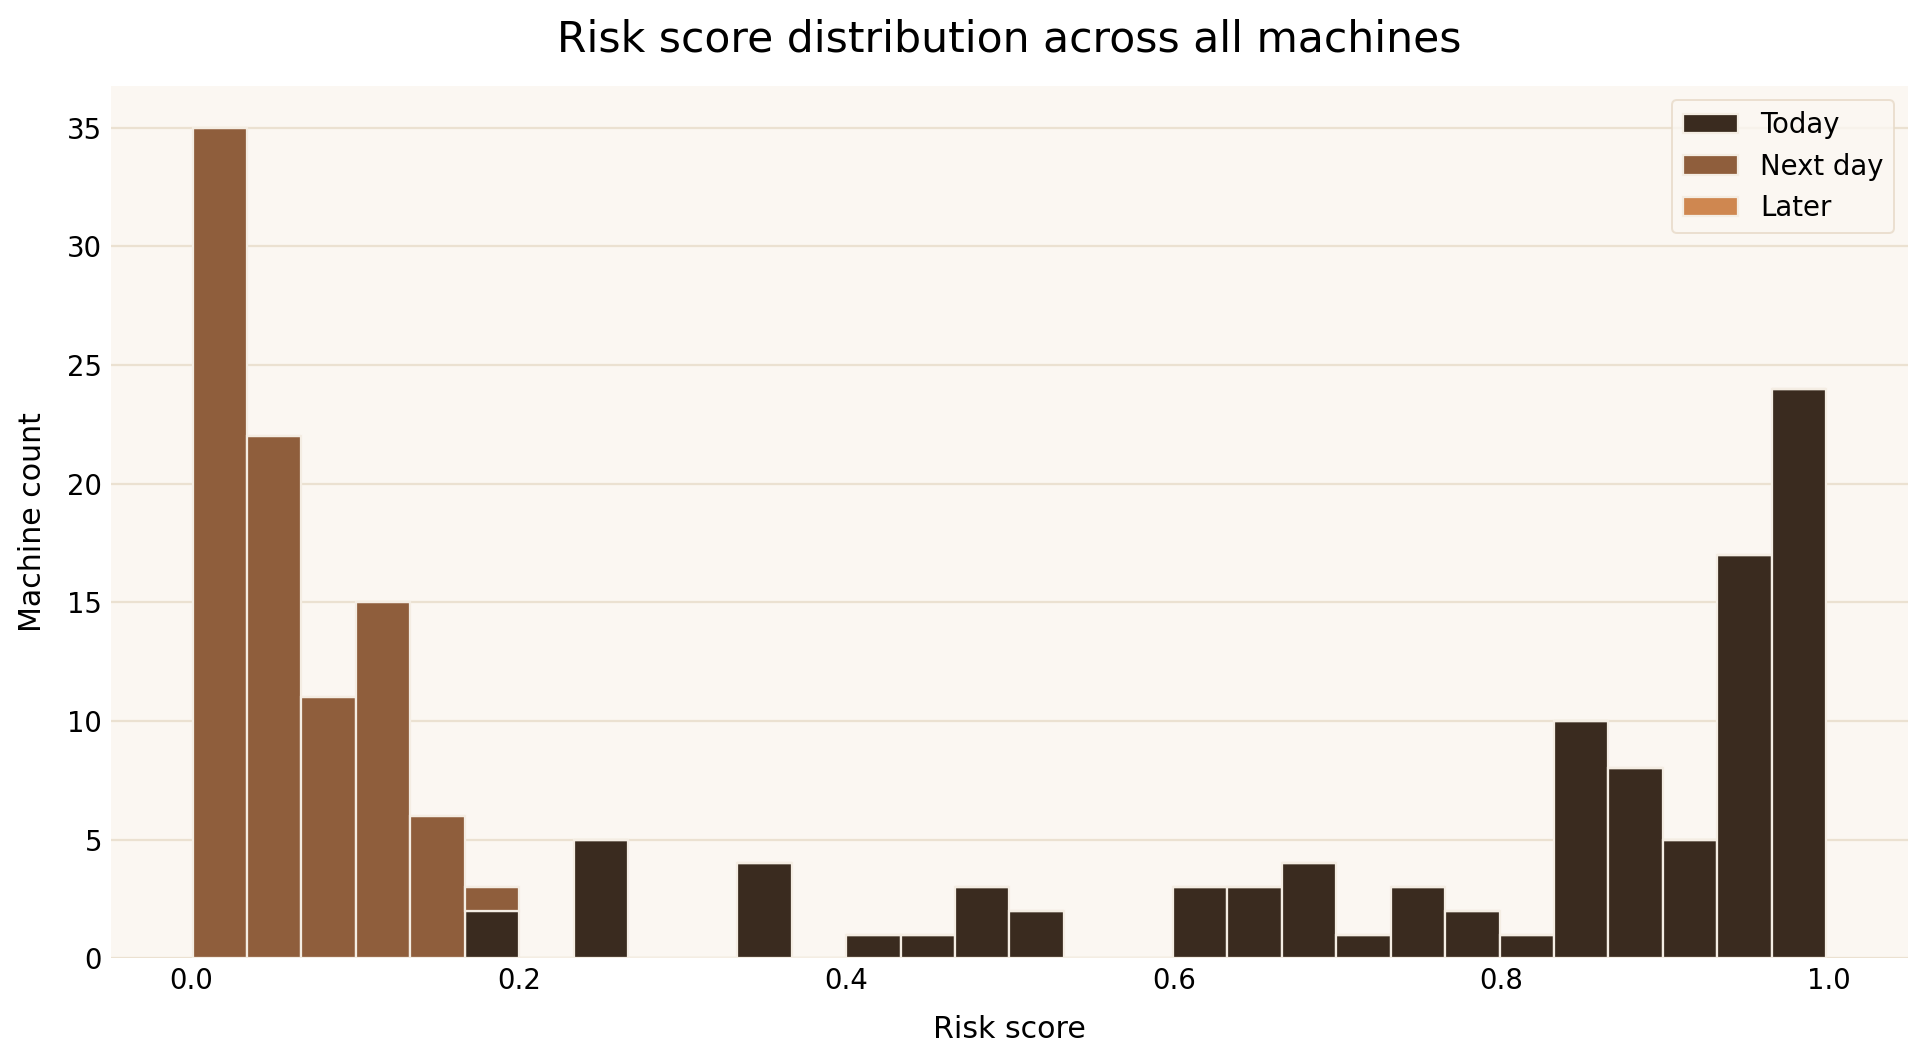

In [14]:
import matplotlib.pyplot as plt

colors = ["#3a2b1f", "#8f5e3c", "#cf8750"]

fig, ax = plt.subplots(figsize=(10.8, 6), dpi=180)
fig.patch.set_facecolor("white")
ax.set_facecolor("#fbf7f2")

ax.hist(
    [
        today_plan["risk_score"],
        next_day_plan["risk_score"],
        backlog_plan["risk_score"],
    ],
    bins=30,
    stacked=True,
    color=colors,
    edgecolor="#f4ede3",
    linewidth=0.9,
    label=["Today", "Next day", "Later"]
)

ax.set_title("Risk score distribution across all machines", fontsize=17, pad=14)
ax.set_xlabel("Risk score", fontsize=12, labelpad=8)
ax.set_ylabel("Machine count", fontsize=12, labelpad=8)

ax.grid(axis="y", color="#eadfce", linewidth=0.9, alpha=0.9)
ax.set_axisbelow(True)
ax.tick_params(axis="both", labelsize=11, length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(
    loc="upper right",
    frameon=True,
    fontsize=11
)
legend.get_frame().set_facecolor("#fbf7f2")
legend.get_frame().set_edgecolor("#e7dac8")
legend.get_frame().set_linewidth(0.8)

plt.tight_layout()
plt.show()

In [15]:
# 14. Triage operator plan: fixed capacity split
# Today capacity = 90
# Next day capacity = 10

# Pick the operating model chosen in the notebook
if "default_plan" in globals():
    selected_model = default_plan["Model"]
elif "overall_best" in globals():
    selected_model = overall_best["Model"]
else:
    raise ValueError("Run the model selection cells first so a final plan exists.")

# Fixed operator capacities
today_capacity = 90
tomorrow_capacity = 10

# Score the test set with the selected model
selected_pipeline = model_pipelines[selected_model]
selected_scores = selected_pipeline.predict_proba(X_test)[:, 1]

# Build a machine level queue
queue = X_test.copy().reset_index(drop=False).rename(columns={"index": "row_id"})
queue["actual_fail"] = np.asarray(y_test)
queue["risk_score"] = selected_scores

# Use an existing machine identifier if one exists, otherwise create one
candidate_id_cols = [
    "machine_id", "Machine_ID", "machine", "Machine", "id", "ID", "asset_id", "Asset_ID"
]
existing_id_cols = [c for c in candidate_id_cols if c in queue.columns]

if existing_id_cols:
    machine_id_col = existing_id_cols[0]
else:
    machine_id_col = "machine_id"
    queue[machine_id_col] = ["M_" + str(i).zfill(5) for i in range(1, len(queue) + 1)]

# Rank by risk and split into today vs next day
queue = queue.sort_values("risk_score", ascending=False).reset_index(drop=True)
queue["risk_rank"] = np.arange(1, len(queue) + 1)

queue["review_day"] = np.select(
    [
        queue["risk_rank"] <= today_capacity,
        queue["risk_rank"] <= today_capacity + tomorrow_capacity,
    ],
    [
        "today",
        "next_day",
    ],
    default="later"
)

# Priority labels
urgent_cutoff = max(1, int(np.ceil(today_capacity * 0.20)))

queue["priority"] = np.select(
    [
        queue["review_day"].eq("today") & (queue["risk_rank"] <= urgent_cutoff),
        queue["review_day"].eq("today"),
        queue["review_day"].eq("next_day"),
    ],
    [
        "urgent",
        "high",
        "medium",
    ],
    default="backlog"
)

# Operator actions
queue["recommended_action"] = np.select(
    [
        queue["priority"].eq("urgent"),
        queue["priority"].eq("high"),
        queue["priority"].eq("medium"),
    ],
    [
        "Inspect now",
        "Inspect by today",
        "Schedule for tomorrow",
    ],
    default="Hold in backlog and monitor"
)

# Keep the most useful columns first
front_cols = [
    machine_id_col, "risk_rank", "risk_score", "review_day",
    "priority", "recommended_action", "actual_fail"
]
other_cols = [c for c in queue.columns if c not in front_cols]
triage_plan = queue[front_cols + other_cols].copy()

# Day specific plans
today_plan = triage_plan[triage_plan["review_day"] == "today"].copy()
next_day_plan = triage_plan[triage_plan["review_day"] == "next_day"].copy()
backlog_plan = triage_plan[triage_plan["review_day"] == "later"].copy()

# Main operator summary
operator_summary = pd.DataFrame([
    {
        "Model": selected_model,
        "Today Review Limit": today_capacity,
        "Next Day Review Limit": tomorrow_capacity,
        "Today Machines": int(len(today_plan)),
        "Next Day Machines": int(len(next_day_plan)),
        "Backlog Remaining": int(len(backlog_plan)),
        "Observed Fails In Today Queue": int(today_plan["actual_fail"].sum()),
        "Observed Fails In Next Day Queue": int(next_day_plan["actual_fail"].sum()),
        "Observed Fails In Backlog": int(backlog_plan["actual_fail"].sum()),
        "Avg Risk Today": round(today_plan["risk_score"].mean(), 4) if len(today_plan) else np.nan,
        "Avg Risk Next Day": round(next_day_plan["risk_score"].mean(), 4) if len(next_day_plan) else np.nan,
        "Avg Risk Backlog": round(backlog_plan["risk_score"].mean(), 4) if len(backlog_plan) else np.nan,
    }
])

# Summary for each action category
priority_order = ["urgent", "high", "medium", "backlog"]

priority_summary = (
    triage_plan
    .groupby(["priority", "recommended_action"], dropna=False)
    .agg(
        machine_count=(machine_id_col, "count"),
        observed_fail_count=("actual_fail", "sum"),
        avg_risk_score=("risk_score", "mean"),
        min_risk_score=("risk_score", "min"),
        max_risk_score=("risk_score", "max"),
    )
    .reset_index()
)

priority_summary["priority"] = pd.Categorical(
    priority_summary["priority"],
    categories=priority_order,
    ordered=True
)
priority_summary = priority_summary.sort_values("priority").reset_index(drop=True)

for col in ["avg_risk_score", "min_risk_score", "max_risk_score"]:
    priority_summary[col] = priority_summary[col].round(4)

# Count summary only, by review day
review_day_counts = (
    triage_plan["review_day"]
    .value_counts(dropna=False)
    .rename_axis("review_day")
    .reset_index(name="machine_count")
)

# Count summary only, by priority
priority_counts = (
    triage_plan["priority"]
    .value_counts(dropna=False)
    .rename_axis("priority")
    .reset_index(name="machine_count")
)

priority_counts["priority"] = pd.Categorical(
    priority_counts["priority"],
    categories=priority_order,
    ordered=True
)
priority_counts = priority_counts.sort_values("priority").reset_index(drop=True)

display(
    operator_summary.style.hide(axis="index")
    .set_caption("Operator triage plan summary")
)

display(
    review_day_counts.style.hide(axis="index")
    .set_caption("Machine counts by review day")
)

display(
    priority_counts.style.hide(axis="index")
    .set_caption("Machine counts by priority")
)

display(
    priority_summary.style.hide(axis="index")
    .set_caption("Summary by priority category and action")
)

display(
    today_plan.head(today_capacity).style.hide(axis="index")
    .set_caption("Machines to review today")
)

display(
    next_day_plan.head(tomorrow_capacity).style.hide(axis="index")
    .set_caption("Machines to review next day")
)

print(f"Use {selected_model} for the live triage queue.")
print(f"Review {today_capacity} machines today and {tomorrow_capacity} machines on the next day.")
print(f"Backlog left after two days: {len(backlog_plan)} machines.")

# Optional exports for handoff
today_plan.to_csv("machines_to_review_today_90.csv", index=False)
next_day_plan.to_csv("machines_to_review_next_day_10.csv", index=False)
triage_plan.to_csv("full_triage_plan_90_10.csv", index=False)
operator_summary.to_csv("operator_summary_90_10.csv", index=False)
review_day_counts.to_csv("review_day_counts_90_10.csv", index=False)
priority_counts.to_csv("priority_counts_90_10.csv", index=False)
priority_summary.to_csv("priority_summary_90_10.csv", index=False)

Model,Today Review Limit,Next Day Review Limit,Today Machines,Next Day Machines,Backlog Remaining,Observed Fails In Today Queue,Observed Fails In Next Day Queue,Observed Fails In Backlog,Avg Risk Today,Avg Risk Next Day,Avg Risk Backlog
Random Forest,90,10,90,10,89,76,3,0,0.841500,0.250500,0.058300


review_day,machine_count
today,90
later,89
next_day,10


priority,machine_count
urgent,18
high,72
medium,10
backlog,89


priority,recommended_action,machine_count,observed_fail_count,avg_risk_score,min_risk_score,max_risk_score
urgent,Inspect now,18,18,0.986100,0.977900,0.998300
high,Inspect by today,72,58,0.805300,0.350900,0.975600
medium,Schedule for tomorrow,10,3,0.250500,0.173500,0.349400
backlog,Hold in backlog and monitor,89,0,0.058300,0.000800,0.160000


machine_id,risk_rank,risk_score,review_day,priority,recommended_action,actual_fail,row_id,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature
M_00138,1,0.998333,today,urgent,Inspect now,1,627,0,1,6,2,5,6,39,5,20
M_00001,2,0.995944,today,urgent,Inspect now,1,309,0,0,6,1,6,6,39,5,15
M_00085,3,0.993889,today,urgent,Inspect now,1,610,20,7,6,1,5,6,54,5,20
M_00148,4,0.992774,today,urgent,Inspect now,1,577,34,4,6,2,6,6,30,6,20
M_00107,5,0.990214,today,urgent,Inspect now,1,245,0,7,6,2,6,6,50,3,14
M_00094,6,0.990103,today,urgent,Inspect now,1,444,0,2,6,1,6,6,64,3,17
M_00180,7,0.990099,today,urgent,Inspect now,1,351,0,1,6,2,5,5,35,5,16
M_00068,8,0.987113,today,urgent,Inspect now,1,596,170,0,6,2,6,6,35,4,20
M_00133,9,0.985389,today,urgent,Inspect now,1,523,0,1,6,1,6,5,45,4,19
M_00121,10,0.985086,today,urgent,Inspect now,1,410,0,2,6,1,6,6,58,6,16


machine_id,risk_rank,risk_score,review_day,priority,recommended_action,actual_fail,row_id,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature
M_00060,91,0.349393,next_day,medium,Schedule for tomorrow,0,901,31,0,5,2,7,3,49,6,24
M_00088,92,0.343020,next_day,medium,Schedule for tomorrow,0,909,20,0,4,3,5,3,49,6,24
M_00026,93,0.264586,next_day,medium,Schedule for tomorrow,0,611,0,3,4,2,7,1,48,3,20
M_00019,94,0.262777,next_day,medium,Schedule for tomorrow,0,688,51,2,5,2,6,1,41,6,21
M_00012,95,0.249922,next_day,medium,Schedule for tomorrow,1,644,310,7,5,2,5,1,56,6,20
M_00167,96,0.242629,next_day,medium,Schedule for tomorrow,0,858,1600,7,5,2,4,2,57,4,23
M_00038,97,0.237664,next_day,medium,Schedule for tomorrow,0,24,19,0,4,2,2,1,45,3,2
M_00091,98,0.194798,next_day,medium,Schedule for tomorrow,1,542,27,7,3,7,4,3,63,2,19
M_00022,99,0.187178,next_day,medium,Schedule for tomorrow,1,516,7300,5,5,2,6,1,37,7,18
M_00035,100,0.173513,next_day,medium,Schedule for tomorrow,0,143,0,6,5,3,6,1,62,4,10


Use Random Forest for the live triage queue.
Review 90 machines today and 10 machines on the next day.
Backlog left after two days: 89 machines.


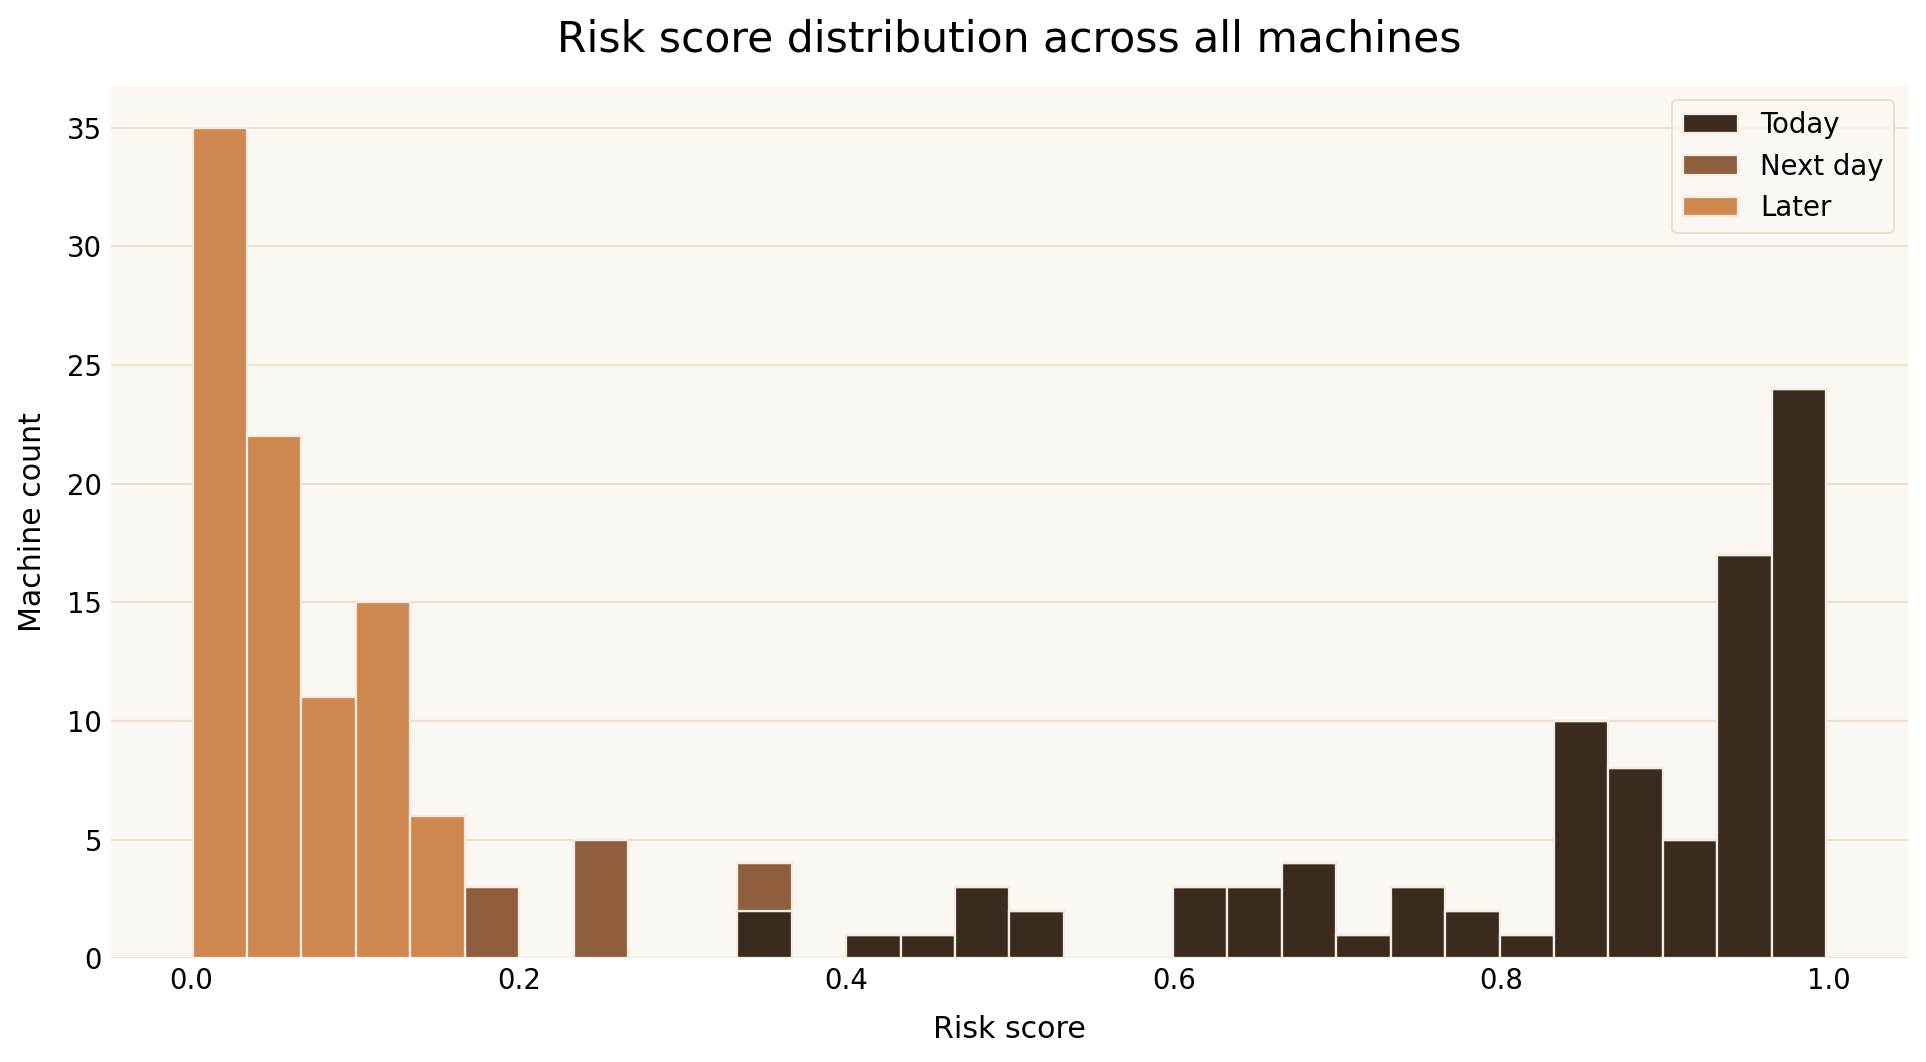

In [16]:
import matplotlib.pyplot as plt

colors = ["#3a2b1f", "#8f5e3c", "#cf8750"]

fig, ax = plt.subplots(figsize=(10.8, 6), dpi=180)
fig.patch.set_facecolor("white")
ax.set_facecolor("#fbf7f2")

ax.hist(
    [
        today_plan["risk_score"],
        next_day_plan["risk_score"],
        backlog_plan["risk_score"],
    ],
    bins=30,
    stacked=True,
    color=colors,
    edgecolor="#f4ede3",
    linewidth=0.9,
    label=["Today", "Next day", "Later"]
)

ax.set_title("Risk score distribution across all machines", fontsize=17, pad=14)
ax.set_xlabel("Risk score", fontsize=12, labelpad=8)
ax.set_ylabel("Machine count", fontsize=12, labelpad=8)

ax.grid(axis="y", color="#eadfce", linewidth=0.9, alpha=0.9)
ax.set_axisbelow(True)
ax.tick_params(axis="both", labelsize=11, length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(
    loc="upper right",
    frameon=True,
    fontsize=11
)
legend.get_frame().set_facecolor("#fbf7f2")
legend.get_frame().set_edgecolor("#e7dac8")
legend.get_frame().set_linewidth(0.8)

plt.tight_layout()
plt.show()

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">



# ~18. Final takeaway

The first ranking table was useful, but it did not answer the final question. That only became clear after I set thresholds and looked at the final error counts.

In this run, Extra Trees is the model I would use.

Why:

- it catches more real failures
- it misses fewer failures
- it sends fewer false alarms for review

That means it is better both for finding risky rows and for keeping the review list cleaner.

SVM RBF is still worth keeping in the notebook because it stayed close enough to make the comparison meaningful. But if I had to choose one model from this run, I would choose Extra Trees.

The main point is practical: the final choice did not come from the first ranking table. It came later, once the cutoff was set and the actual counts of missed failures and false alarms were visible.


Also,

The important change happens early.

In this notebook, the practical break point is 1:3.

Below 1:3, the best plan is backlog tolerant.

At 1:3 and above, the best plan becomes backlog free and then stays unchanged.

That means the recommendation is sensitive only in the low ratio range. Once delayed failures are priced even moderately above false alarms, the preferred policy settles at the same model and review limit.


</div>